In [ ]:
import os, time, warnings, random, json
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (roc_auc_score, precision_recall_curve,
                              average_precision_score, roc_curve,
                              confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[DEVICE]  {DEVICE} | PyTorch {torch.__version__}")

# ── Plot style ────────────────────────────────────────────────────────────────
DARK = {
    'figure.facecolor':'#0D1117','axes.facecolor':'#161B22','axes.edgecolor':'#30363D',
    'axes.labelcolor':'#E6EDF3','xtick.color':'#8B949E','ytick.color':'#8B949E',
    'text.color':'#E6EDF3','grid.color':'#21262D','grid.linestyle':'--',
    'grid.alpha':0.6,'font.family':'monospace',
}
plt.rcParams.update(DARK)
CMAP_STAB  = LinearSegmentedColormap.from_list('stab',  ['#FF4444','#FF8800','#44FF88'], N=256)
CMAP_RISK  = LinearSegmentedColormap.from_list('risk',  ['#0D1117','#FF4444','#FFDD00'], N=256)



[DEVICE]  cuda | PyTorch 2.10.0+cu128


# SECTION 1: DATA PIPELINE

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class DataConfig:
    dataset_name : str   = 'CIFAR10'   # CIFAR10 is harder → richer dynamics
    train_size   : int   = 10000
    val_size     : int   = 2000
    batch_size   : int   = 128
    noise_ratio  : float = 0.08        # 8% → enough for meaningful detection
    inject_noise : bool  = True
    num_workers  : int   = 2
    data_root    : str   = './data'


class NoisySubsetDataset(Dataset):
    """
    Wraps a Subset and stores per-sample original indices + a noise mask.
    FIX: v1 lost track of which LOCAL positions were noisy. This class
    maintains a clean mapping: local_pos → original_dataset_idx, and
    separately tracks which local positions received label corruption.
    """
    def __init__(self, base_dataset, indices: List[int],
                 noise_ratio: float, num_classes: int, seed: int = SEED):
        self.base    = base_dataset
        self.indices = indices                  # local pos → original idx
        self.N       = len(indices)

        rng = np.random.RandomState(seed)

        # Copy targets for the subset
        self.targets = np.array([base_dataset.targets[i] for i in indices])
        self.original_targets = self.targets.copy()

        # Inject noise — track LOCAL positions
        n_noisy = int(self.N * noise_ratio)
        self.noisy_local_positions: Set[int] = set(
            rng.choice(self.N, size=n_noisy, replace=False).tolist()
        )
        for pos in self.noisy_local_positions:
            orig = self.original_targets[pos]
            wrong = [c for c in range(num_classes) if c != orig]
            self.targets[pos] = int(rng.choice(wrong))

        print(f"  [NOISE]  Injected {n_noisy} noisy labels "
              f"({noise_ratio*100:.1f}% of {self.N})")

    def __len__(self):
        return self.N

    def __getitem__(self, pos):
        img, _ = self.base[self.indices[pos]]
        label  = int(self.targets[pos])
        return img, label, pos          # ← return LOCAL position too


def collate_with_pos(batch):
    imgs   = torch.stack([b[0] for b in batch])
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    pos    = torch.tensor([b[2] for b in batch], dtype=torch.long)
    return imgs, labels, pos


class ValSubsetDataset(Dataset):
    """Clean validation subset (no noise). Also returns local position."""
    def __init__(self, base_dataset, indices: List[int]):
        self.base    = base_dataset
        self.indices = indices
        self.targets = np.array([base_dataset.targets[i] for i in indices])
        self.N       = len(indices)

    def __len__(self): return self.N

    def __getitem__(self, pos):
        img, _ = self.base[self.indices[pos]]
        return img, int(self.targets[pos]), pos


def build_dataloaders(cfg: DataConfig):
    print(f"\n[DATA]   Loading {cfg.dataset_name}...")

    if cfg.dataset_name == 'MNIST':
        T_tr = transforms.Compose([
            transforms.RandomAffine(degrees=10, translate=(0.1,0.1)),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,),(0.3081,))
        ])
        T_te = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,),(0.3081,))
        ])
        DS = torchvision.datasets.MNIST
        num_classes, input_shape = 10, (1,28,28)

    else:  # CIFAR-10 — harder, more interesting dynamics
        T_tr = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.3,0.3,0.3,0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
        ])
        T_te = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
        ])
        DS = torchvision.datasets.CIFAR10
        num_classes, input_shape = 10, (3,32,32)

    base_tr = DS(root=cfg.data_root, train=True,  download=True, transform=T_tr)
    base_te = DS(root=cfg.data_root, train=False, download=True, transform=T_te)

    rng = np.random.RandomState(SEED)
    all_idx = rng.permutation(len(base_tr))
    tr_idx  = all_idx[:cfg.train_size].tolist()
    va_idx  = all_idx[cfg.train_size:cfg.train_size+cfg.val_size].tolist()
    te_idx  = rng.permutation(len(base_te))[:2000].tolist()

    # ── Build noisy training dataset ─────────────────────────────────────────
    train_ds = NoisySubsetDataset(base_tr, tr_idx, cfg.noise_ratio,
                                   num_classes, seed=SEED)
    val_ds   = ValSubsetDataset(base_tr, va_idx)
    test_ds  = ValSubsetDataset(base_te, te_idx)

    kw = dict(collate_fn=collate_with_pos, num_workers=cfg.num_workers,
              pin_memory=(DEVICE.type=='cuda'))

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                               shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size,
                               shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size,
                               shuffle=False, **kw)

    print(f"[DATA]   Train:{len(train_ds)} Val:{len(val_ds)} "
          f"Test:{len(test_ds)} | Classes:{num_classes} | Shape:{input_shape}")

    return dict(train=train_loader, val=val_loader, test=test_loader,
                train_ds=train_ds, val_ds=val_ds,
                num_classes=num_classes, input_shape=input_shape,
                noisy_local_positions=train_ds.noisy_local_positions,
                train_size=len(train_ds), val_size=len(val_ds))



# SECTION 2: MODEL

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: MODEL
# ─────────────────────────────────────────────────────────────────────────────

class ResBlock(nn.Module):
    def __init__(self, ic, oc, stride=1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ic, oc, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc),
        )
        self.skip = nn.Sequential()
        if stride != 1 or ic != oc:
            self.skip = nn.Sequential(
                nn.Conv2d(ic, oc, 1, stride=stride, bias=False),
                nn.BatchNorm2d(oc))
    def forward(self, x):
        return F.relu(self.body(x) + self.skip(x))


class DiagnosticCNN(nn.Module):
    """
    Moderate-capacity CNN.
    Deliberately not over-engineered so that learning dynamics
    are observable rather than trivially fast (no dynamics to study).
    """
    def __init__(self, input_shape, num_classes):
        super().__init__()
        ic = input_shape[0]
        self.stem   = nn.Sequential(
            nn.Conv2d(ic,32,3,padding=1,bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.layer1 = ResBlock(32, 64,  stride=2)
        self.layer2 = ResBlock(64, 128, stride=2)
        self.layer3 = ResBlock(128,128, stride=1)
        self.drop   = nn.Dropout(0.3)

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            feat  = F.adaptive_avg_pool2d(
                self.layer3(self.layer2(self.layer1(self.stem(dummy)))), (2,2))
            flat  = feat.view(1,-1).shape[1]

        self.head = nn.Sequential(
            nn.Linear(flat,256), nn.ReLU(inplace=True),
            nn.Dropout(0.2), nn.Linear(256, num_classes))

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, return_probs=False):
        f = self.stem(x)
        f = self.layer1(f); f = self.layer2(f); f = self.layer3(f)
        f = F.adaptive_avg_pool2d(f,(2,2))
        f = self.drop(f.view(f.size(0),-1))
        logits = self.head(f)
        if return_probs:
            return logits, F.softmax(logits, dim=1)
        return logits



# SECTION 3: TEMPORAL DATABASE

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: TEMPORAL DATABASE
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class EpochRecord:
    epoch          : int
    split          : str
    local_positions: np.ndarray   # position in the subset dataset
    predictions    : np.ndarray
    true_labels    : np.ndarray
    probabilities  : np.ndarray   # [N, C]
    per_sample_loss: np.ndarray
    correct_mask   : np.ndarray
    timestamp      : float = field(default_factory=time.time)

    @property
    def accuracy(self): return float(self.correct_mask.mean())
    @property
    def mean_loss(self): return float(self.per_sample_loss.mean())
    @property
    def mean_confidence(self): return float(self.probabilities.max(axis=1).mean())


class TemporalDB:
    def __init__(self, train_size:int, val_size:int, num_classes:int):
        self.train_size  = train_size
        self.val_size    = val_size
        self.num_classes = num_classes
        self.records: Dict[str, List[EpochRecord]] = {'train':[], 'val':[]}
        self.epoch_metrics: List[dict] = []
        self._cache: dict = {}

    def add(self, rec: EpochRecord):
        self.records[rec.split].append(rec)
        self._cache.clear()

    def log_metrics(self, epoch, tl, ta, vl, va, lr):
        self.epoch_metrics.append(dict(epoch=epoch,train_loss=tl,train_acc=ta,
                                        val_loss=vl,val_acc=va,lr=lr))

    def _build(self, split):
        key = f'built_{split}'
        if key in self._cache: return
        recs = self.records[split]
        if not recs: return
        N  = self.train_size if split=='train' else self.val_size
        E  = len(recs)
        # Pre-allocate aligned matrices
        correctness = np.zeros((N,E), dtype=bool)
        confidence  = np.zeros((N,E), dtype=np.float32)
        prob_tensor = np.zeros((N,E,self.num_classes), dtype=np.float32)
        pred_matrix = np.full((N,E), -1, dtype=np.int16)
        true_labels = np.full(N, -1, dtype=np.int16)

        for e_idx, rec in enumerate(recs):
            for arr_pos, local_pos in enumerate(rec.local_positions):
                p = int(local_pos)
                if p >= N: continue
                correctness[p, e_idx] = rec.correct_mask[arr_pos]
                confidence[p,  e_idx] = rec.probabilities[arr_pos].max()
                prob_tensor[p, e_idx] = rec.probabilities[arr_pos]
                pred_matrix[p, e_idx] = rec.predictions[arr_pos]
                true_labels[p]        = rec.true_labels[arr_pos]

        self._cache[f'corr_{split}']  = correctness
        self._cache[f'conf_{split}']  = confidence
        self._cache[f'prob_{split}']  = prob_tensor
        self._cache[f'pred_{split}']  = pred_matrix
        self._cache[f'true_{split}']  = true_labels
        self._cache[f'epochs_{split}']= [r.epoch for r in recs]
        self._cache[key] = True

    def correctness(self, s='val'):  self._build(s); return self._cache[f'corr_{s}']
    def confidence(self, s='val'):   self._build(s); return self._cache[f'conf_{s}']
    def prob_tensor(self, s='val'):  self._build(s); return self._cache[f'prob_{s}']
    def pred_matrix(self, s='val'):  self._build(s); return self._cache[f'pred_{s}']
    def true_labels(self, s='val'):  self._build(s); return self._cache[f'true_{s}']
    def epoch_list(self, s='val'):   self._build(s); return self._cache[f'epochs_{s}']
    def metrics_df(self): return pd.DataFrame(self.epoch_metrics)



# SECTION 4: TRAINING ENGINE

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: TRAINING ENGINE
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class TrainConfig:
    epochs     : int   = 40
    lr         : float = 0.001
    wd         : float = 1e-4
    optimizer  : str   = 'adam'
    scheduler  : str   = 'cosine'
    log_every  : int   = 1


def eval_split(model, loader, split, epoch, num_classes) -> EpochRecord:
    model.eval()
    crit = nn.CrossEntropyLoss(reduction='none')
    positions, preds, labels, probs, losses = [],[],[],[],[]

    with torch.no_grad():
        for imgs, lbls, pos in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)
            logits, pb = model(imgs, return_probs=True)
            ls = crit(logits, lbls)
            positions.append(pos.numpy())
            preds.append(logits.argmax(1).cpu().numpy())
            labels.append(lbls.cpu().numpy())
            probs.append(pb.cpu().numpy())
            losses.append(ls.cpu().numpy())

    pos_arr  = np.concatenate(positions)
    pred_arr = np.concatenate(preds)
    lbl_arr  = np.concatenate(labels)
    prob_arr = np.concatenate(probs, axis=0)
    loss_arr = np.concatenate(losses)
    corr_arr = (pred_arr == lbl_arr)

    return EpochRecord(epoch=epoch, split=split,
                       local_positions=pos_arr, predictions=pred_arr,
                       true_labels=lbl_arr, probabilities=prob_arr,
                       per_sample_loss=loss_arr, correct_mask=corr_arr)


def run_training(model, db: TemporalDB, data: dict,
                 cfg: TrainConfig) -> TemporalDB:
    print("\n" + "═"*62)
    print("  TEMPORAL FRAMEWORK v2.0 — TRAINING")
    print("═"*62)

    crit = nn.CrossEntropyLoss()
    if cfg.optimizer == 'adam':
        opt = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
    else:
        opt = optim.SGD(model.parameters(), lr=cfg.lr,
                         momentum=0.9, weight_decay=cfg.wd, nesterov=True)

    if cfg.scheduler == 'cosine':
        sched = optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=cfg.epochs, eta_min=1e-6)
    elif cfg.scheduler == 'onecycle':
        sched = optim.lr_scheduler.OneCycleLR(
            opt, max_lr=cfg.lr*10,
            steps_per_epoch=len(data['train']), epochs=cfg.epochs)
    else:
        sched = None

    for epoch in range(1, cfg.epochs+1):
        t0 = time.time()
        model.train()
        total_loss, correct, total = 0., 0, 0

        for imgs, lbls, _ in data['train']:
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(imgs)
            loss   = crit(logits, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            if cfg.scheduler == 'onecycle' and sched:
                sched.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)

        if sched and cfg.scheduler != 'onecycle':
            sched.step()

        tl, ta = total_loss/total, correct/total

        # Temporal logging
        if epoch % cfg.log_every == 0 or epoch in (1, cfg.epochs):
            val_rec = eval_split(model, data['val'],   'val',   epoch, data['num_classes'])
            tr_rec  = eval_split(model, data['train'], 'train', epoch, data['num_classes'])
            db.add(val_rec); db.add(tr_rec)
            vl, va = val_rec.mean_loss, val_rec.accuracy
        else:
            vl, va = 0., 0.

        lr_now = opt.param_groups[0]['lr']
        db.log_metrics(epoch, tl, ta, vl, va, lr_now)

        print(f"  Ep[{epoch:3d}/{cfg.epochs}] "
              f"tr_L={tl:.4f} tr_A={ta:.4f} | "
              f"va_L={vl:.4f} va_A={va:.4f} | "
              f"lr={lr_now:.6f} | {time.time()-t0:.1f}s")

    # Final summary
    mdf = db.metrics_df()
    best = mdf.loc[mdf['val_acc'].idxmax()]
    print(f"\n  Best val acc: {best['val_acc']:.4f} @ epoch {int(best['epoch'])}")
    print("═"*62)
    return db


print("[v2-CORE] Data, Model, DB, Training defined.")

[v2-CORE] Data, Model, DB, Training defined.


# SECTION 5: FIXED NOVEL METRICS ENGINE

In [ ]:
# =============================================================================
# SECTION 5: FIXED NOVEL METRICS ENGINE
# =============================================================================

class MetricsEngine:
    """
    Computes FSI, CDM, TSS indexed by LOCAL POSITION (0..N-1).
    This guarantees alignment with noisy_local_positions.
    """

    def __init__(self, db: TemporalDB, split: str = 'train'):
        self.db    = db
        self.split = split
        self.C  = db.correctness(split)   # [N, E]
        self.CF = db.confidence(split)    # [N, E]
        self.PT = db.prob_tensor(split)   # [N, E, C]
        self.TL = db.true_labels(split)   # [N]
        self.EP = db.epoch_list(split)    # list of epoch numbers
        self.N, self.E = self.C.shape
        print(f"\n[METRICS-v2] split={split}  N={self.N}  E={self.E}")

    # ── FSI ───────────────────────────────────────────────────────────────────
    def compute_fsi(self) -> np.ndarray:
        """
        FSI[i] = Σ_e  I(correct[i,e]=1 ∧ correct[i,e+1]=0) × weight(e)
        weight(e) = 1 + e/E  (later forgetting penalized more)
        Returns array shape [N].
        """
        C   = self.C.astype(int)
        w   = 1.0 + np.arange(1, self.E) / self.E          # [E-1]
        fgt = (C[:, :-1] == 1) & (C[:, 1:] == 0)           # [N, E-1]
        fsi = (fgt * w[np.newaxis, :]).sum(axis=1)          # [N]
        return fsi.astype(np.float32)

    # ── CDM ───────────────────────────────────────────────────────────────────
    def compute_cdm(self) -> np.ndarray:
        """
        CDM[i] = std(conf[i,:]) + 0.5 × mean|Δconf[i,:]|
        Returns array shape [N].
        """
        conf_std  = self.CF.std(axis=1)
        drift_vel = np.abs(np.diff(self.CF, axis=1)).mean(axis=1)
        cdm       = conf_std + 0.5 * drift_vel
        return cdm.astype(np.float32)

    # ── TSS ───────────────────────────────────────────────────────────────────
    def compute_tss(self) -> np.ndarray:
        """
        TSS[i] = 0.5×streak + 0.3×monotonicity + 0.2×final_window
        streak      = Σ run_len²  / E²
        monotonicity= Pearson(epoch_idx, correctness[i,:]), mapped to [0,1]
        final_window= mean correctness in last 20% epochs
        """
        C = self.C.astype(float)
        N, E = self.N, self.E

        # streak score
        streak = np.zeros(N, dtype=np.float32)
        for i in range(N):
            run = 0; sq = 0
            for v in self.C[i]:
                if v: run += 1
                else: sq += run**2; run = 0
            sq += run**2
            streak[i] = sq / (E*E)

        # monotonicity
        ei     = np.arange(E, dtype=float)
        ei_n   = (ei - ei.mean()) / (ei.std() + 1e-8)
        mono   = np.zeros(N, dtype=np.float32)
        for i in range(N):
            c_n = (C[i] - C[i].mean()) / (C[i].std() + 1e-8)
            mono[i] = float(np.clip((ei_n * c_n).mean(), -1, 1))
        mono = (mono + 1) / 2   # → [0,1]

        # final window
        w     = max(1, int(E * 0.2))
        final = C[:, -w:].mean(axis=1).astype(np.float32)

        tss = 0.5*streak + 0.3*mono + 0.2*final
        return tss.astype(np.float32)

    # ── Confidence slope ──────────────────────────────────────────────────────
    def compute_conf_slope(self) -> np.ndarray:
        """Linear regression slope of confidence over epochs. [N]"""
        ei = np.linspace(0, 1, self.E)
        slope = np.array([np.polyfit(ei, self.CF[i], 1)[0]
                           for i in range(self.N)], dtype=np.float32)
        return slope

    # ── Master metrics DataFrame ──────────────────────────────────────────────
    def compute_all(self, noisy_positions: set = None) -> pd.DataFrame:
        """
        Returns per-sample DataFrame with FSI, CDM, TSS, mislabel_score,
        and ground-truth is_noisy column.
        KEY FIX: indexed by local_position which aligns with noisy_positions.
        """
        fsi   = self.compute_fsi()
        cdm   = self.compute_cdm()
        tss   = self.compute_tss()
        slope = self.compute_conf_slope()

        C = self.C.astype(float)
        mean_acc    = C.mean(axis=1)
        final_acc   = C[:, -1]
        mean_conf   = self.CF.mean(axis=1)
        final_conf  = self.CF[:, -1]
        cal_gap     = np.abs(self.CF - C).mean(axis=1)

        # Wrong-answer confidence: final confidence when prediction is WRONG
        wrong_conf = np.where(final_acc == 0, final_conf, 0.0).astype(np.float32)

        # Category
        cat = np.where(tss > 0.7, 'Stably Learned',
              np.where(tss > 0.4, 'Partially Learned',
              np.where(tss > 0.1, 'Unstable', 'Not Learned')))

        df = pd.DataFrame({
            'local_pos'    : np.arange(self.N),
            'true_label'   : self.TL,
            'fsi'          : fsi,
            'cdm'          : cdm,
            'tss'          : tss,
            'conf_slope'   : slope,
            'mean_acc'     : mean_acc,
            'final_acc'    : final_acc,
            'mean_conf'    : mean_conf,
            'final_conf'   : final_conf,
            'cal_gap'      : cal_gap,
            'wrong_conf'   : wrong_conf,
            'category'     : cat,
        })

        # ── FIXED mislabel score ──────────────────────────────────────────────
        # Signals: high FSI, high CDM, low TSS, high wrong_conf
        # Normalize each to [0,1] then combine
        def norm(x):
            mn, mx = x.min(), x.max()
            return (x - mn) / (mx - mn + 1e-8)

        df['mislabel_score'] = (
            0.30 * norm(df['fsi'].values) +
            0.30 * norm(df['cdm'].values) +
            0.25 * (1 - norm(df['tss'].values)) +
            0.15 * norm(df['wrong_conf'].values)
        )

        # Composite risk
        df['risk_score'] = (
            0.35 * norm(df['fsi'].values) +
            0.35 * norm(df['cdm'].values) +
            0.30 * (1 - norm(df['tss'].values))
        )
        df['is_high_risk'] = df['risk_score'] > 0.6

        # Ground truth noise label
        if noisy_positions:
            df['is_noisy'] = df['local_pos'].isin(noisy_positions)
        else:
            df['is_noisy'] = False

        return df.reset_index(drop=True)


# SECTION 6: METRIC VALIDATION — Correlation + Predictive Power

In [ ]:

# =============================================================================
# SECTION 6: METRIC VALIDATION — Correlation + Predictive Power
# =============================================================================

class MetricValidator:
    """
    Validates FSI, CDM, TSS scientifically:
    1. Correlation with final error rate
    2. AUC-ROC for mislabel detection
    3. Early-detection analysis: at which epoch does temporal signal emerge?
    4. Baseline comparison: temporal metrics vs loss-curve detection
    """

    def __init__(self, df: pd.DataFrame, db: TemporalDB,
                 noisy_positions: set, split: str = 'train'):
        self.df              = df
        self.db              = db
        self.noisy_positions = noisy_positions
        self.split           = split
        self.has_noisy       = len(noisy_positions) > 0

    # ── 1. Correlation with final error ──────────────────────────────────────
    def validate_metric_correlations(self) -> pd.DataFrame:
        """
        Computes Pearson + Spearman correlations between each metric
        and binary final error (1=wrong, 0=correct).
        Scientific claim: "FSI/CDM positively correlate with misclassification"
        """
        df = self.df.copy()
        error = (1 - df['final_acc']).values  # 1 = misclassified

        results = []
        for metric in ['fsi', 'cdm', 'tss', 'mislabel_score', 'risk_score']:
            x = df[metric].values
            if metric in ('tss',):  # TSS is inverse — high TSS = low error
                x = -x
            pr, pp = pearsonr(x, error)
            sr, sp = spearmanr(x, error)
            results.append({
                'metric': metric,
                'pearson_r': pr, 'pearson_p': pp,
                'spearman_r': sr, 'spearman_p': sp,
                'significant': pp < 0.05,
            })

        corr_df = pd.DataFrame(results)
        print("\n[VALIDATION] Metric-Error Correlations:")
        print(corr_df[['metric','pearson_r','spearman_r','significant']].to_string(index=False))
        return corr_df

    # ── 2. Mislabel Detection AUC ─────────────────────────────────────────────
    def validate_mislabel_detection(self) -> dict:
        """
        Evaluates mislabel_score as a classifier for noisy labels.
        Reports: AUC-ROC, Average Precision, Precision@K for K=20,50,100.
        Compares against baseline (loss-based ranking).
        """
        if not self.has_noisy:
            print("[VALIDATION] No noisy positions provided — skipping mislabel AUC")
            return {}

        df = self.df.copy()
        y_true = df['is_noisy'].astype(int).values     # ground truth

        # ── Temporal score ────────────────────────────────────────────────────
        y_score_temporal = df['mislabel_score'].values
        auc_temporal = roc_auc_score(y_true, y_score_temporal)
        ap_temporal  = average_precision_score(y_true, y_score_temporal)

        # ── Baseline: rank by MEAN LOSS (standard approach) ──────────────────
        # Use final epoch record's per-sample loss
        recs = self.db.records[self.split]
        if recs:
            # Build mean loss per local position
            mean_loss = np.zeros(len(df))
            loss_counts = np.zeros(len(df))
            for rec in recs:
                for arr_pos, lp in enumerate(rec.local_positions):
                    p = int(lp)
                    if p < len(mean_loss):
                        mean_loss[p]   += rec.per_sample_loss[arr_pos]
                        loss_counts[p] += 1
            loss_counts = np.maximum(loss_counts, 1)
            mean_loss   /= loss_counts
            y_score_loss = mean_loss
        else:
            y_score_loss = np.zeros(len(df))

        auc_loss = roc_auc_score(y_true, y_score_loss)
        ap_loss  = average_precision_score(y_true, y_score_loss)

        # ── Baseline: rank by FINAL CONFIDENCE (common heuristic) ────────────
        y_score_conf = df['final_conf'].values
        auc_conf = roc_auc_score(y_true, y_score_conf)
        ap_conf  = average_precision_score(y_true, y_score_conf)

        # ── Precision@K ───────────────────────────────────────────────────────
        def precision_at_k(scores, labels, k):
            topk = np.argsort(scores)[-k:]
            return labels[topk].sum() / k

        results = {}
        for name, scores in [('temporal_fsicdt', y_score_temporal),
                               ('baseline_loss',   y_score_loss),
                               ('baseline_conf',   y_score_conf)]:
            results[name] = {
                'auc_roc': roc_auc_score(y_true, scores),
                'avg_prec': average_precision_score(y_true, scores),
                'prec@20':  precision_at_k(scores, y_true, 20),
                'prec@50':  precision_at_k(scores, y_true, 50),
                'prec@100': precision_at_k(scores, y_true, 100) if len(y_true)>100 else 0,
            }

        print("\n[VALIDATION] Mislabel Detection Performance:")
        print(f"  {'Method':<22} {'AUC-ROC':>8} {'AvgPrec':>8} "
              f"{'P@20':>8} {'P@50':>8} {'P@100':>8}")
        print("  " + "─"*60)
        for name, r in results.items():
            print(f"  {name:<22} {r['auc_roc']:8.3f} {r['avg_prec']:8.3f} "
                  f"{r['prec@20']:8.3f} {r['prec@50']:8.3f} {r['prec@100']:8.3f}")

        return results

    # ── 3. Early Detection Analysis ───────────────────────────────────────────
    def validate_early_detection(self, top_k: int = 50) -> pd.DataFrame:
        """
        KEY RESEARCH CLAIM: Temporal metrics can DETECT problems EARLIER
        than standard validation loss divergence.

        Method:
          1. For each epoch e (from epoch 2 onwards), compute partial metrics
             using only the first e epochs of data.
          2. Measure P@K with partial metrics.
          3. Find FIRST epoch where P@K > 0.3 (meaningful signal).
          4. Compare against epoch where val_loss first shows overfitting signal.
        """
        if not self.has_noisy:
            return pd.DataFrame()

        db  = self.db
        recs = db.records[self.split]
        E_total = len(recs)
        N = self.db.train_size if self.split == 'train' else self.db.val_size
        noisy_arr = self.df['is_noisy'].values  # [N] boolean

        rows = []
        for e in range(2, E_total + 1):
            # Build partial matrices using first e records
            sub_recs = recs[:e]
            C_part = np.zeros((N, e), dtype=bool)
            CF_part = np.zeros((N, e), dtype=np.float32)
            loss_part = np.zeros((N, e), dtype=np.float32)

            for ei, rec in enumerate(sub_recs):
                for arr_pos, lp in enumerate(rec.local_positions):
                    p = int(lp)
                    if p >= N: continue
                    C_part[p,  ei] = rec.correct_mask[arr_pos]
                    CF_part[p, ei] = rec.probabilities[arr_pos].max()
                    loss_part[p,ei]= rec.per_sample_loss[arr_pos]

            # Partial FSI
            w   = 1.0 + np.arange(1, e) / e
            fgt = (C_part[:,:-1].astype(int)==1) & (C_part[:,1:].astype(int)==0)
            fsi_partial = (fgt * w[np.newaxis,:]).sum(axis=1) if e > 1 else np.zeros(N)

            # Partial CDM
            cdm_partial = (CF_part.std(axis=1) + 0.5*np.abs(np.diff(CF_part,axis=1)).mean(axis=1)
                           if e > 1 else np.zeros(N))

            # Partial TSS
            mean_acc = C_part.astype(float).mean(axis=1)
            tss_partial = mean_acc  # simplified proxy for partial

            # Combined score
            def norm(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
            combined = 0.4*norm(fsi_partial) + 0.35*norm(cdm_partial) + 0.25*(1-norm(tss_partial))

            # Baseline: mean loss
            ml = loss_part.mean(axis=1)
            ml_score = norm(ml)

            k = min(top_k, N)
            prec_temporal = noisy_arr[np.argsort(combined)[-k:]].mean()
            prec_baseline = noisy_arr[np.argsort(ml_score)[-k:]].mean()

            rows.append(dict(
                epoch=sub_recs[-1].epoch,
                epoch_idx=e,
                prec_temporal=float(prec_temporal),
                prec_baseline=float(prec_baseline),
            ))

        result_df = pd.DataFrame(rows)

        # Find first epoch each method exceeds 0.3 precision
        thresh = 0.25
        t_first = result_df.loc[result_df['prec_temporal'] >= thresh, 'epoch']
        b_first = result_df.loc[result_df['prec_baseline'] >= thresh, 'epoch']

        t_ep = int(t_first.iloc[0]) if len(t_first) else -1
        b_ep = int(b_first.iloc[0]) if len(b_first) else -1

        print(f"\n[VALIDATION] Early Detection (P@{top_k} ≥ {thresh}):")
        print(f"  Temporal method first signals at epoch: {t_ep}")
        print(f"  Loss baseline first signals at epoch:   {b_ep}")
        if t_ep > 0 and b_ep > 0 and t_ep < b_ep:
            print(f"  ✓ Temporal method detects {b_ep - t_ep} epochs earlier")
        elif t_ep > 0 and b_ep < 0:
            print(f"  ✓ Temporal detects; loss-baseline never reaches threshold")

        return result_df

    # ── 4. Logistic Regression on metrics → error prediction ─────────────────
    def validate_error_prediction(self) -> dict:
        """
        Can FSI+CDM+TSS at epoch E//2 predict final misclassification?
        Train a logistic regression on mid-training metrics → final error.
        Reports AUC-ROC as scientific claim.
        """
        df = self.df.copy()
        X  = df[['fsi','cdm','tss','mean_conf','cal_gap']].values
        y  = (1 - df['final_acc']).astype(int).values

        if y.sum() < 10:
            print("[VALIDATION] Too few errors for logistic regression")
            return {}

        scaler = StandardScaler()
        X_s    = scaler.fit_transform(X)

        from sklearn.model_selection import cross_val_score
        lr  = LogisticRegression(max_iter=1000, class_weight='balanced')
        aucs = cross_val_score(lr, X_s, y, cv=5, scoring='roc_auc')

        print(f"\n[VALIDATION] Error prediction (5-fold CV):")
        print(f"  Features: FSI, CDM, TSS, mean_conf, cal_gap")
        print(f"  AUC-ROC:  {aucs.mean():.3f} ± {aucs.std():.3f}")
        print(f"  → Temporal metrics predict misclassification with AUC={aucs.mean():.3f}")

        return {'auc_mean': float(aucs.mean()), 'auc_std': float(aucs.std())}


# SECTION 7: FORGETTING DETECTOR + PHASE TRANSITIONS

In [ ]:


# =============================================================================
# SECTION 7: FORGETTING DETECTOR + PHASE TRANSITIONS
# =============================================================================

class ForgettingDetector:
    def __init__(self, db: TemporalDB, df: pd.DataFrame,
                 split='train', noisy_positions: set = None):
        self.db      = db
        self.df      = df
        self.split   = split
        self.noisy   = noisy_positions or set()
        self.C       = db.correctness(split).astype(int)
        self.N, self.E = self.C.shape
        self.epochs  = db.epoch_list(split)

    def event_log(self) -> pd.DataFrame:
        rows = []
        for i in range(self.N):
            for e in range(self.E - 1):
                if self.C[i,e]==1 and self.C[i,e+1]==0:
                    rows.append(dict(local_pos=i, epoch=self.epochs[e+1],
                                     event='forgetting', is_noisy=i in self.noisy))
                elif self.C[i,e]==0 and self.C[i,e+1]==1:
                    rows.append(dict(local_pos=i, epoch=self.epochs[e+1],
                                     event='recovery', is_noisy=i in self.noisy))
        df = pd.DataFrame(rows) if rows else pd.DataFrame(
            columns=['local_pos','epoch','event','is_noisy'])
        print(f"[EVENTS]  {(df['event']=='forgetting').sum()} forgetting | "
              f"{(df['event']=='recovery').sum()} recovery")
        return df

    def phase_transitions(self) -> pd.DataFrame:
        fr = []
        for e in range(self.E - 1):
            n = ((self.C[:,e]==1) & (self.C[:,e+1]==0)).sum()
            fr.append(dict(epoch=self.epochs[e+1], fr=n/self.N, n_forgot=int(n)))
        df = pd.DataFrame(fr)
        if len(df) < 2: return df
        mu, sigma = df['fr'].mean(), df['fr'].std()
        df['z']    = (df['fr'] - mu) / (sigma + 1e-8)
        df['is_pt'] = df['z'] > 2.0
        print(f"[PHASES]  {df['is_pt'].sum()} phase transitions detected")
        return df

    def class_forgetting_matrix(self) -> pd.DataFrame:
        """Per-class forgetting rates × epochs."""
        tl = self.db.true_labels(self.split)
        classes = sorted(np.unique(tl[tl >= 0]))
        rows = []
        for e in range(self.E - 1):
            for c in classes:
                mask = (tl == c)
                n_class = mask.sum()
                if n_class == 0: continue
                n_fgt = ((self.C[mask,e]==1) & (self.C[mask,e+1]==0)).sum()
                rows.append(dict(epoch=self.epochs[e+1],
                                 cls=c, fr=n_fgt/n_class))
        return pd.DataFrame(rows)


print("[v2-METRICS] MetricsEngine, Validator, ForgettingDetector defined.")

[v2-METRICS] MetricsEngine, Validator, ForgettingDetector defined.


# SECTION 8: RESEARCH-GRADE VISUALIZATION SUITE v2.0

In [ ]:
# =============================================================================
# SECTION 8: RESEARCH-GRADE VISUALIZATION SUITE v2.0
# =============================================================================
# New plots added:
#   - AUC-ROC curves: temporal vs baselines
#   - Precision-Recall curves for mislabel detection
#   - Early detection timeline comparison
#   - Metric correlation heatmap
#   - Metric distributions with statistical annotation
#   - Class forgetting progression heatmap
#   - Per-sample timeline (6 panels: high-risk, stable, noisy)
# =============================================================================

class ResearchVisualizer:

    def __init__(self, db: TemporalDB, df: pd.DataFrame,
                 events_df: pd.DataFrame, phases_df: pd.DataFrame,
                 val_results: dict, early_df: pd.DataFrame,
                 corr_df: pd.DataFrame, error_pred: dict,
                 noisy_positions: set, split: str = 'train'):

        self.db              = db
        self.df              = df
        self.events_df       = events_df
        self.phases_df       = phases_df
        self.val_results     = val_results
        self.early_df        = early_df
        self.corr_df         = corr_df
        self.error_pred      = error_pred
        self.noisy           = noisy_positions
        self.split           = split

        self.C   = db.correctness(split)
        self.CF  = db.confidence(split)
        self.N, self.E = self.C.shape
        self.EP  = db.epoch_list(split)
        self.mdf = db.metrics_df()

    # ── PLOT 1: Training Overview ─────────────────────────────────────────────

    def plot_training_overview(self, save=None):
        fig = plt.figure(figsize=(20, 12), facecolor='#0D1117')
        fig.suptitle('TEMPORAL DYNAMICS v2.0 — TRAINING OVERVIEW',
                     fontsize=15, color='#58A6FF', fontweight='bold', y=0.99)
        gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

        mdf = self.mdf
        ep  = mdf['epoch'].values
        # Only non-zero val entries
        v_mask = mdf['val_acc'] > 0
        v_ep = mdf.loc[v_mask, 'epoch'].values
        v_acc = mdf.loc[v_mask, 'val_acc'].values
        v_loss = mdf.loc[v_mask, 'val_loss'].values

        # Loss
        ax = fig.add_subplot(gs[0,0])
        ax.plot(ep, mdf['train_loss'], '#58A6FF', lw=2, label='Train')
        ax.plot(v_ep, v_loss, '#FF7B72', lw=2, ls='--', label='Val')
        ax.fill_between(ep, mdf['train_loss'], alpha=0.1, color='#58A6FF')
        ax.set_title('Loss Curves', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.3)
        ax.grid(True, alpha=0.3)

        # Accuracy
        ax = fig.add_subplot(gs[0,1])
        ax.plot(ep, mdf['train_acc'], '#3FB950', lw=2, label='Train')
        ax.plot(v_ep, v_acc, '#FFA657', lw=2, ls='--', label='Val')
        best_ep = v_ep[np.argmax(v_acc)] if len(v_ep)>0 else 0
        best_va = v_acc.max() if len(v_acc)>0 else 0
        ax.axvline(best_ep, color='#FFDD00', lw=1.5, ls=':', alpha=0.8)
        ax.annotate(f'Best={best_va:.4f}@{best_ep}',
                    xy=(best_ep, best_va), xytext=(best_ep+1, best_va-0.05),
                    color='#FFDD00', fontsize=8)
        ax.set_title('Accuracy Curves', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.set_ylim([0, 1.05])
        ax.legend(fontsize=9, framealpha=0.3)
        ax.grid(True, alpha=0.3)

        # LR
        ax = fig.add_subplot(gs[0,2])
        ax.plot(ep, mdf['lr'], '#D2A8FF', lw=2)
        ax.fill_between(ep, mdf['lr'], alpha=0.2, color='#D2A8FF')
        ax.set_title('LR Schedule', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)

        # Generalization gap
        ax = fig.add_subplot(gs[0,3])
        gap = mdf['train_acc'].values - mdf['val_acc'].values
        gap = np.where(mdf['val_acc'].values > 0, gap, np.nan)
        valid = ~np.isnan(gap)
        ax.plot(ep[valid], gap[valid], '#F78166', lw=2)
        ax.fill_between(ep[valid], gap[valid], alpha=0.2, color='#F78166')
        ax.axhline(0.10, color='#FFDD00', lw=1.5, ls='--',
                    label='Overfit threshold')
        ax.set_title('Generalization Gap', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.3)
        ax.grid(True, alpha=0.3)

        # TSS category bar
        ax = fig.add_subplot(gs[1,0])
        cat_c = {'Stably Learned':'#3FB950','Partially Learned':'#FFA657',
                  'Unstable':'#FF7B72','Not Learned':'#FF4444'}
        counts = self.df['category'].value_counts()
        bars = ax.bar(range(len(counts)), counts.values,
                       color=[cat_c.get(c,'#8B949E') for c in counts.index],
                       alpha=0.85, edgecolor='none')
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=20, ha='right',
                            color='#8B949E', fontsize=8)
        ax.set_title('TSS Learning Categories', color='#E6EDF3', fontsize=11)
        ax.set_ylabel('Count', color='#8B949E')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, v in zip(bars, counts.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                    f'{v}\n({100*v/len(self.df):.1f}%)',
                    ha='center', va='bottom', color='#E6EDF3', fontsize=8)

        # Phase transitions
        ax = fig.add_subplot(gs[1,1])
        if not self.phases_df.empty and 'fr' in self.phases_df.columns:
            ph = self.phases_df
            ax.plot(ph['epoch'], ph['fr'], '#FF7B72', lw=2)
            ax.fill_between(ph['epoch'], ph['fr'], alpha=0.2, color='#FF7B72')
            pts = ph[ph['is_pt']]
            ax.scatter(pts['epoch'], pts['fr'], color='#FFDD00', s=100,
                        zorder=5, marker='*', label=f'{len(pts)} transitions')
            ax.legend(fontsize=9, framealpha=0.3)
        ax.set_title('Forgetting Rate / Epoch', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.grid(True, alpha=0.3)

        # Calibration evolution
        ax = fig.add_subplot(gs[1,2])
        cal_ep, cal_conf, cal_acc = [], [], []
        for rec in self.db.records[self.split]:
            cal_ep.append(rec.epoch)
            cal_conf.append(float(rec.probabilities.max(axis=1).mean()))
            cal_acc.append(float(rec.correct_mask.mean()))
        if cal_ep:
            ax.plot(cal_ep, cal_conf, '#58A6FF', lw=2, label='Mean Conf')
            ax.plot(cal_ep, cal_acc,  '#3FB950', lw=2, label='Mean Acc')
            ax.fill_between(cal_ep, cal_conf, cal_acc,
                             alpha=0.2, color='#FF7B72', label='Cal Gap')
        ax.set_title('Calibration: Conf vs Acc', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.3)
        ax.set_ylim([0, 1.05])
        ax.grid(True, alpha=0.3)

        # FSI vs CDM scatter
        ax = fig.add_subplot(gs[1,3])
        sc = ax.scatter(self.df['fsi'], self.df['cdm'],
                          c=self.df['tss'], cmap='RdYlGn',
                          alpha=0.35, s=15, vmin=0, vmax=1)
        if self.noisy:
            noisy_df = self.df[self.df['is_noisy']]
            ax.scatter(noisy_df['fsi'], noisy_df['cdm'],
                        color='#FFDD00', s=50, marker='X', zorder=5,
                        label=f'Noisy ({len(noisy_df)})')
            ax.legend(fontsize=9, framealpha=0.5)
        plt.colorbar(sc, ax=ax, label='TSS', fraction=0.03)
        ax.set_title('FSI vs CDM (color=TSS)', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('FSI', color='#8B949E')
        ax.set_ylabel('CDM', color='#8B949E')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 2: Mislabel Detection — AUC + PR curves ──────────────────────────

    def plot_mislabel_validation(self, save=None):
        if not self.val_results or not self.noisy:
            print("[VIZ] No mislabel validation results to plot"); return

        fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0D1117')
        fig.suptitle('MISLABEL DETECTION — Temporal Method vs Baselines',
                     fontsize=14, color='#FF7B72', fontweight='bold', y=1.02)

        y_true = self.df['is_noisy'].astype(int).values

        # AUC-ROC
        ax = axes[0]
        colors_ = {'temporal_fsicdt':'#58A6FF',
                    'baseline_loss':'#FF7B72',
                    'baseline_conf':'#FFA657'}
        labels_ = {'temporal_fsicdt':'Temporal (FSI+CDM+TSS)',
                    'baseline_loss':'Baseline: Mean Loss',
                    'baseline_conf':'Baseline: Confidence'}
        score_map = {
            'temporal_fsicdt': self.df['mislabel_score'].values,
            'baseline_loss':   self._get_mean_loss_scores(),
            'baseline_conf':   self.df['final_conf'].values,
        }
        for name, scores in score_map.items():
            fpr, tpr, _ = roc_curve(y_true, scores)
            auc_ = roc_auc_score(y_true, scores)
            ax.plot(fpr, tpr, color=colors_[name], lw=2.5,
                     label=f'{labels_[name]} (AUC={auc_:.3f})')
        ax.plot([0,1],[0,1], '#30363D', lw=1.5, ls='--')
        ax.fill_between([0,1],[0,1], alpha=0.05, color='#30363D')
        ax.set_title('AUC-ROC: Noisy Label Detection', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('False Positive Rate', color='#8B949E')
        ax.set_ylabel('True Positive Rate', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        # Precision-Recall
        ax = axes[1]
        baseline_prec = y_true.mean()
        ax.axhline(baseline_prec, color='#30363D', lw=1.5, ls='--',
                    label=f'Random ({baseline_prec:.3f})')
        for name, scores in score_map.items():
            prec_, rec_, _ = precision_recall_curve(y_true, scores)
            ap_  = average_precision_score(y_true, scores)
            ax.plot(rec_, prec_, color=colors_[name], lw=2.5,
                     label=f'{labels_[name]} (AP={ap_:.3f})')
        ax.set_title('Precision-Recall: Noisy Detection', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Recall', color='#8B949E')
        ax.set_ylabel('Precision', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.5)
        ax.set_ylim([0, 1.05])
        ax.grid(True, alpha=0.3)

        # Precision@K bar chart
        ax = axes[2]
        ks = [10, 20, 50, 100]
        width = 0.25
        x = np.arange(len(ks))
        for j, (name, scores) in enumerate(score_map.items()):
            precs = []
            for k in ks:
                topk = np.argsort(scores)[-k:]
                precs.append(y_true[topk].mean())
            ax.bar(x + j*width, precs, width, label=labels_[name],
                    color=colors_[name], alpha=0.8, edgecolor='none')
        ax.axhline(baseline_prec, color='#FFDD00', lw=1.5, ls='--',
                    label='Random baseline')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f'P@{k}' for k in ks], color='#8B949E')
        ax.set_title('Precision@K', color='#E6EDF3', fontsize=11)
        ax.set_ylabel('Precision', color='#8B949E')
        ax.legend(fontsize=8, framealpha=0.5)
        ax.set_ylim([0, min(1.05, max(0.5,
            max([r['prec@20'] for r in self.val_results.values()])*1.5))])
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 3: Early Detection Timeline ──────────────────────────────────────

    def plot_early_detection(self, save=None):
        if self.early_df is None or self.early_df.empty:
            print("[VIZ] No early detection data"); return

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0D1117')
        fig.suptitle('EARLY DETECTION — Temporal Method vs Loss Baseline',
                     fontsize=14, color='#3FB950', fontweight='bold', y=1.02)

        ed = self.early_df

        # Precision over epochs
        ax = axes[0]
        ax.plot(ed['epoch'], ed['prec_temporal'], '#58A6FF', lw=2.5,
                 label='Temporal (FSI+CDM+TSS)', zorder=3)
        ax.plot(ed['epoch'], ed['prec_baseline'], '#FF7B72', lw=2.5,
                 ls='--', label='Baseline (Mean Loss)', zorder=3)
        ax.fill_between(ed['epoch'], ed['prec_temporal'], ed['prec_baseline'],
                         alpha=0.15, color='#3FB950',
                         label='Temporal advantage')
        ax.axhline(0.25, color='#FFDD00', lw=1.5, ls=':',
                    label='Useful threshold (0.25)')

        thresh = 0.25
        t_first = ed.loc[ed['prec_temporal'] >= thresh, 'epoch']
        b_first = ed.loc[ed['prec_baseline'] >= thresh, 'epoch']
        if len(t_first):
            ax.axvline(t_first.iloc[0], color='#58A6FF', lw=1.5, ls=':',
                        alpha=0.8)
            ax.annotate(f'Temporal\n@ep{t_first.iloc[0]}',
                         xy=(t_first.iloc[0], thresh),
                         xytext=(t_first.iloc[0]+1, thresh+0.05),
                         color='#58A6FF', fontsize=8,
                         arrowprops=dict(arrowstyle='->', color='#58A6FF'))
        if len(b_first):
            ax.axvline(b_first.iloc[0], color='#FF7B72', lw=1.5, ls=':',
                        alpha=0.8)
            ax.annotate(f'Baseline\n@ep{b_first.iloc[0]}',
                         xy=(b_first.iloc[0], thresh),
                         xytext=(b_first.iloc[0]+1, thresh-0.05),
                         color='#FF7B72', fontsize=8,
                         arrowprops=dict(arrowstyle='->', color='#FF7B72'))
        ax.set_title('Mislabel Detection Precision Over Training',
                      color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.set_ylabel('Precision@K', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.5)
        ax.set_ylim([0, 1.0])
        ax.grid(True, alpha=0.3)

        # Delta: how much better is temporal at each epoch
        ax = axes[1]
        delta = ed['prec_temporal'] - ed['prec_baseline']
        c_bars = ['#3FB950' if d >= 0 else '#FF7B72' for d in delta]
        ax.bar(ed['epoch'], delta, color=c_bars, alpha=0.8, width=0.8)
        ax.axhline(0, color='#8B949E', lw=1)
        ax.set_title('Temporal Advantage (Δ Precision vs Baseline)',
                      color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')
        ax.set_ylabel('ΔPrecision', color='#8B949E')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 4: Metric Validation Dashboard ───────────────────────────────────

    def plot_metric_validation(self, save=None):
        fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='#0D1117')
        fig.suptitle('METRIC VALIDATION — Correlations, Distributions & Predictive Power',
                     fontsize=14, color='#D2A8FF', fontweight='bold', y=1.02)

        df = self.df
        error = (1 - df['final_acc']).values

        # FSI vs error scatter
        ax = axes[0,0]
        ax.scatter(df['fsi'], error, c='#58A6FF', alpha=0.3, s=15)
        m, b = np.polyfit(df['fsi'], error, 1)
        x_line = np.linspace(df['fsi'].min(), df['fsi'].max(), 100)
        ax.plot(x_line, m*x_line+b, '#FFDD00', lw=2.5, label=f'r={pearsonr(df["fsi"],error)[0]:.3f}')
        ax.set_title('FSI vs Final Error', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('FSI', color='#8B949E'); ax.set_ylabel('Error (1=wrong)', color='#8B949E')
        ax.legend(fontsize=10, framealpha=0.5); ax.grid(True, alpha=0.3)

        # CDM vs error scatter
        ax = axes[0,1]
        ax.scatter(df['cdm'], error, c='#D2A8FF', alpha=0.3, s=15)
        m, b = np.polyfit(df['cdm'], error, 1)
        x_line = np.linspace(df['cdm'].min(), df['cdm'].max(), 100)
        ax.plot(x_line, m*x_line+b, '#FFDD00', lw=2.5, label=f'r={pearsonr(df["cdm"],error)[0]:.3f}')
        ax.set_title('CDM vs Final Error', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('CDM', color='#8B949E'); ax.set_ylabel('Error', color='#8B949E')
        ax.legend(fontsize=10, framealpha=0.5); ax.grid(True, alpha=0.3)

        # TSS vs error scatter
        ax = axes[0,2]
        ax.scatter(df['tss'], error, c='#3FB950', alpha=0.3, s=15)
        m, b = np.polyfit(df['tss'], error, 1)
        x_line = np.linspace(df['tss'].min(), df['tss'].max(), 100)
        ax.plot(x_line, m*x_line+b, '#FFDD00', lw=2.5,
                 label=f'r={pearsonr(df["tss"],error)[0]:.3f}')
        ax.set_title('TSS vs Final Error', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('TSS', color='#8B949E'); ax.set_ylabel('Error', color='#8B949E')
        ax.legend(fontsize=10, framealpha=0.5); ax.grid(True, alpha=0.3)

        # Correlation bar chart
        ax = axes[1,0]
        if self.corr_df is not None and not self.corr_df.empty:
            cd = self.corr_df
            x = np.arange(len(cd))
            colors_corr = ['#3FB950' if r > 0 else '#FF7B72' for r in cd['pearson_r']]
            ax.bar(x - 0.2, cd['pearson_r'].abs(),  0.35, label='|Pearson r|',
                    color='#58A6FF', alpha=0.8)
            ax.bar(x + 0.2, cd['spearman_r'].abs(), 0.35, label='|Spearman r|',
                    color='#FFA657', alpha=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(cd['metric'], rotation=15, ha='right',
                                color='#8B949E', fontsize=9)
            ax.set_title('Correlation with Final Error', color='#E6EDF3', fontsize=11)
            ax.set_ylabel('|Correlation|', color='#8B949E')
            ax.legend(fontsize=9, framealpha=0.3)
            ax.grid(True, alpha=0.3, axis='y')

        # Error prediction AUC summary
        ax = axes[1,1]
        ax.set_facecolor('#161B22')
        info_lines = [
            "ERROR PREDICTION (5-fold CV)",
            "",
            "Features: FSI + CDM + TSS",
            "         + mean_conf + cal_gap",
            "",
        ]
        if self.error_pred:
            auc_m = self.error_pred.get('auc_mean', 0)
            auc_s = self.error_pred.get('auc_std', 0)
            info_lines += [
                f"AUC-ROC: {auc_m:.3f} ± {auc_s:.3f}",
                "",
                "Interpretation:",
                "> 0.7 = Good predictive power",
                "> 0.8 = Strong predictive power",
                "",
                "CLAIM: Temporal metrics predict",
                "misclassification BEFORE training",
                "ends.",
            ]
        for idx, line in enumerate(info_lines):
            color = '#FFDD00' if 'AUC' in line or 'CLAIM' in line else '#E6EDF3'
            fontsize = 10 if 'AUC' in line or 'CLAIM' in line else 9
            ax.text(0.05, 0.95 - idx*0.07, line, transform=ax.transAxes,
                     fontsize=fontsize, color=color, verticalalignment='top',
                     fontfamily='monospace')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title('Metric Predictive Power Summary', color='#E6EDF3', fontsize=11)

        # FSI distribution by noisy vs clean
        ax = axes[1,2]
        if self.noisy:
            noisy_fsi = df.loc[df['is_noisy'], 'fsi'].values
            clean_fsi = df.loc[~df['is_noisy'], 'fsi'].values
            bins = np.linspace(0, df['fsi'].max(), 40)
            ax.hist(clean_fsi, bins=bins, color='#58A6FF', alpha=0.6,
                     label=f'Clean (n={len(clean_fsi)})', density=True)
            ax.hist(noisy_fsi, bins=bins, color='#FF7B72', alpha=0.7,
                     label=f'Noisy (n={len(noisy_fsi)})', density=True)
            # KS test
            ks_stat, ks_p = stats.ks_2samp(clean_fsi, noisy_fsi)
            ax.set_title(f'FSI: Clean vs Noisy (KS p={ks_p:.4f})',
                          color='#E6EDF3', fontsize=11)
            ax.legend(fontsize=9, framealpha=0.5)
        else:
            ax.hist(df['fsi'], bins=40, color='#58A6FF', alpha=0.8)
            ax.set_title('FSI Distribution', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('FSI', color='#8B949E')
        ax.set_ylabel('Density', color='#8B949E')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 5: Forgetting Heatmaps ───────────────────────────────────────────

    def plot_forgetting_heatmaps(self, n=120, save=None):
        fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor='#0D1117')
        fig.suptitle('FORGETTING HEATMAPS — Correctness & Confidence Over Epochs',
                     fontsize=14, color='#FF7B72', fontweight='bold', y=1.01)

        by_fsi = self.df.sort_values('fsi', ascending=False).head(n)
        positions = by_fsi['local_pos'].values
        valid = positions[positions < self.N][:n]

        C_mat  = self.C[valid].astype(float)
        CF_mat = self.CF[valid]

        def hm(ax, mat, cmap, title, cbar_label):
            im = ax.imshow(mat, aspect='auto', cmap=cmap,
                            interpolation='nearest', vmin=0, vmax=1)
            ax.set_title(title, color='#E6EDF3', fontsize=11, pad=10)
            ax.set_xlabel('Epoch Index', color='#8B949E')
            ax.set_ylabel(f'Sample (top {len(valid)} by FSI)', color='#8B949E')
            step = max(1, self.E//10)
            ax.set_xticks(range(0, self.E, step))
            ax.set_xticklabels(self.EP[::step], color='#8B949E', fontsize=8)
            ax.set_yticks([])
            # Mark noisy rows
            for row_i, pos in enumerate(valid):
                if pos in self.noisy:
                    ax.annotate('N', xy=(-0.5, row_i),
                                 xycoords=('data', 'data'),
                                 fontsize=6, color='#FFDD00', ha='right')
            plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.02)

        hm(axes[0], C_mat,  CMAP_STAB, 'Correctness (1=correct)', 'Correct')
        hm(axes[1], CF_mat, 'plasma',   'Confidence (max softmax)', 'Confidence')

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 6: Sample Learning Timelines ─────────────────────────────────────

    def plot_sample_timelines(self, n=6, mode='high_risk', save=None):
        mode_map = {
            'high_risk': ('risk_score', False, 'HIGH-RISK SAMPLES'),
            'stable':    ('tss',        False, 'STABLY LEARNED'),
            'noisy':     ('mislabel_score', False, 'NOISY LABEL CANDIDATES'),
        }
        sort_col, asc, title = mode_map.get(mode, mode_map['high_risk'])
        if mode == 'noisy' and self.noisy:
            sel = self.df[self.df['is_noisy']].sort_values('risk_score', ascending=False).head(n)
        else:
            sel = self.df.sort_values(sort_col, ascending=asc).head(n)

        fig, axes = plt.subplots(n, 1, figsize=(18, 3.2*n), facecolor='#0D1117')
        fig.suptitle(f'SAMPLE TIMELINES — {title}',
                     fontsize=13, color='#FFA657', fontweight='bold', y=1.01)
        if n == 1: axes = [axes]

        for ax_i, (_, row) in enumerate(sel.iterrows()):
            if ax_i >= n: break
            ax  = axes[ax_i]
            pos = int(row['local_pos'])
            if pos >= self.N:
                ax.set_visible(False); continue

            conf = self.CF[pos]
            corr = self.C[pos].astype(int)

            # Background: green=correct, red=wrong
            for e_i in range(len(self.EP)):
                x0 = self.EP[e_i]
                x1 = self.EP[e_i+1] if e_i+1 < len(self.EP) else x0+1
                ax.axvspan(x0, x1, alpha=0.35,
                            color='#1A3A2A' if corr[e_i] else '#3A1A1A')
            # Confidence line
            ax.plot(self.EP, conf, '#58A6FF', lw=2, zorder=4)
            ax.fill_between(self.EP, conf, alpha=0.15, color='#58A6FF')
            # Forgetting events
            for e_i in range(len(self.EP)-1):
                if corr[e_i]==1 and corr[e_i+1]==0:
                    ax.axvline(self.EP[e_i+1], color='#FF4444', lw=2,
                                ls='--', alpha=0.9, zorder=5)

            is_noisy = pos in self.noisy
            ax.set_ylim([-0.05, 1.15])
            ax.set_xlim([self.EP[0]-0.5, self.EP[-1]+0.5])
            ax.set_ylabel('Conf', color='#8B949E', fontsize=9)
            tag = ' ⚠ NOISY LABEL' if is_noisy else ''
            ax.set_title(
                f"pos={pos} cls={int(row['true_label'])}{tag} | "
                f"FSI={row['fsi']:.2f}  CDM={row['cdm']:.4f}  "
                f"TSS={row['tss']:.3f}  Risk={row['risk_score']:.3f}",
                color='#FFDD00' if is_noisy else '#E6EDF3',
                fontsize=9, loc='left', pad=3)
            ax.grid(True, alpha=0.3, axis='y')

        axes[-1].set_xlabel('Epoch', color='#8B949E', fontsize=10)
        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── PLOT 7: Class-level Forgetting Progression ────────────────────────────

    def plot_class_forgetting(self, class_fr_df: pd.DataFrame, save=None):
        fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0D1117')
        fig.suptitle('CLASS-LEVEL LEARNING DYNAMICS',
                     fontsize=14, color='#3FB950', fontweight='bold', y=1.02)
        df = self.df
        classes = sorted(df['true_label'].unique())
        cmap10  = plt.cm.tab10

        # Per-class FSI
        ax = axes[0]
        c_fsi = df.groupby('true_label')['fsi'].mean().reindex(classes)
        ax.bar(classes, c_fsi, color=[cmap10(c/10) for c in classes], alpha=0.85)
        ax.set_title('Mean FSI per Class', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Class', color='#8B949E'); ax.set_ylabel('Mean FSI', color='#8B949E')
        ax.set_xticks(classes); ax.grid(True, alpha=0.3, axis='y')

        # Per-class TSS
        ax = axes[1]
        c_tss = df.groupby('true_label')['tss'].mean().reindex(classes)
        bars = ax.bar(classes, c_tss, color=[cmap10(c/10) for c in classes], alpha=0.85)
        ax.axhline(df['tss'].mean(), color='#FFDD00', lw=1.5, ls='--', label='Overall mean')
        ax.set_title('Mean TSS per Class', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Class', color='#8B949E'); ax.set_ylabel('Mean TSS', color='#8B949E')
        ax.legend(fontsize=9, framealpha=0.3)
        ax.set_xticks(classes); ax.grid(True, alpha=0.3, axis='y')

        # Class forgetting rate heatmap over epochs
        ax = axes[2]
        if not class_fr_df.empty:
            pivot = class_fr_df.pivot(index='cls', columns='epoch', values='fr').fillna(0)
            im = ax.imshow(pivot.values, aspect='auto', cmap='Reds',
                            interpolation='nearest', vmin=0)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f'cls{c}' for c in pivot.index], color='#8B949E', fontsize=8)
            ax.set_xticks(range(0, pivot.shape[1], max(1, pivot.shape[1]//8)))
            ax.set_xticklabels(list(pivot.columns)[::max(1,pivot.shape[1]//8)],
                                color='#8B949E', fontsize=7, rotation=45)
            plt.colorbar(im, ax=ax, label='Forgetting Rate', fraction=0.03)
        ax.set_title('Class Forgetting Rate × Epoch', color='#E6EDF3', fontsize=11)
        ax.set_xlabel('Epoch', color='#8B949E')

        plt.tight_layout()
        if save: plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='#0D1117')
        plt.show(); plt.close()

    # ── Helper ────────────────────────────────────────────────────────────────
    def _get_mean_loss_scores(self) -> np.ndarray:
        N  = len(self.df)
        ml = np.zeros(N, dtype=np.float32)
        mc = np.zeros(N, dtype=np.float32)
        for rec in self.db.records[self.split]:
            for arr_pos, lp in enumerate(rec.local_positions):
                p = int(lp)
                if p < N:
                    ml[p] += rec.per_sample_loss[arr_pos]
                    mc[p] += 1
        return ml / np.maximum(mc, 1)

    def run_all(self, out='./viz_v2'):
        os.makedirs(out, exist_ok=True)
        print(f"\n[VIZ-v2] Saving all plots → {out}/")
        self.plot_training_overview(save=f'{out}/01_training_overview.png')
        self.plot_mislabel_validation(save=f'{out}/02_mislabel_detection.png')
        self.plot_early_detection(save=f'{out}/03_early_detection.png')
        self.plot_metric_validation(save=f'{out}/04_metric_validation.png')
        self.plot_forgetting_heatmaps(save=f'{out}/05_forgetting_heatmaps.png')
        self.plot_sample_timelines(mode='high_risk', save=f'{out}/06_high_risk.png')
        self.plot_sample_timelines(mode='stable',    save=f'{out}/07_stable.png')
        if self.noisy:
            self.plot_sample_timelines(mode='noisy', save=f'{out}/08_noisy_labels.png')
        print(f"[VIZ-v2] Done — {out}/")


print("[v2-VIZ] ResearchVisualizer defined.")

[v2-VIZ] ResearchVisualizer defined.


# SECTION 9: RESEARCH INSIGHTS REPORTER v2.0

In [ ]:
# =============================================================================
# SECTION 9: RESEARCH INSIGHTS REPORTER v2.0
# =============================================================================

class ResearchReporter:
    """
    Generates the complete scientific report with quantitative claims,
    baseline comparisons, and statistical significance.
    """
    def __init__(self, df, db, val_results, corr_df, error_pred,
                 early_df, events_df, noisy_positions):
        self.df        = df
        self.db        = db
        self.vr        = val_results
        self.corr_df   = corr_df
        self.ep        = error_pred
        self.early_df  = early_df
        self.ev_df     = events_df
        self.noisy     = noisy_positions
        self.mdf       = db.metrics_df()

    def generate(self):
        df  = self.df
        mdf = self.mdf
        print("\n" + "█"*72)
        print("  TEMPORAL LEARNING DYNAMICS FRAMEWORK v2.0")
        print("  RESEARCH DIAGNOSTIC REPORT")
        print("█"*72)

        # ── 1. Training health ────────────────────────────────────────────────
        vm = mdf[mdf['val_acc']>0]
        last = vm.iloc[-1]
        best = vm.loc[vm['val_acc'].idxmax()]
        gap  = float(mdf['train_acc'].iloc[-1]) - float(last['val_acc'])
        print(f"\n  ▌ 1. TRAINING HEALTH")
        print(f"  {'─'*42}")
        print(f"  Best val accuracy : {best['val_acc']:.4f}  @ epoch {int(best['epoch'])}")
        print(f"  Final train acc   : {mdf['train_acc'].iloc[-1]:.4f}")
        print(f"  Final val acc     : {last['val_acc']:.4f}")
        verdict = ("⚠ OVERFIT" if gap>0.15 else "⚡ MILD OVERFIT" if gap>0.07 else "✓ HEALTHY")
        print(f"  Gen. gap          : {gap:.4f}  {verdict}")

        # ── 2. FSI findings ───────────────────────────────────────────────────
        print(f"\n  ▌ 2. FORGETTING SEVERITY INDEX (FSI)")
        print(f"  {'─'*42}")
        print(f"  Mean FSI          : {df['fsi'].mean():.3f}")
        print(f"  Max FSI           : {df['fsi'].max():.2f}")
        print(f"  High-FSI (>3)     : {(df['fsi']>3).sum()} ({100*(df['fsi']>3).mean():.1f}%)")
        mc = df.groupby('true_label')['fsi'].mean().idxmax()
        print(f"  Most-forgotten cls: {mc}")
        if self.corr_df is not None and not self.corr_df.empty:
            row = self.corr_df[self.corr_df['metric']=='fsi']
            if len(row):
                r, p = float(row['pearson_r'].iloc[0]), float(row['pearson_p'].iloc[0])
                sig = '✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'
                print(f"  Corr w/ error     : r={r:.3f}  p={p:.4f}  {sig}")

        # ── 3. CDM findings ───────────────────────────────────────────────────
        print(f"\n  ▌ 3. CONFIDENCE DRIFT METRIC (CDM)")
        print(f"  {'─'*42}")
        print(f"  Mean CDM          : {df['cdm'].mean():.5f}")
        print(f"  High-drift (>0.15): {(df['cdm']>0.15).sum()} ({100*(df['cdm']>0.15).mean():.1f}%)")
        print(f"  Mean cal. gap     : {df['cal_gap'].mean():.4f}")
        if self.corr_df is not None and not self.corr_df.empty:
            row = self.corr_df[self.corr_df['metric']=='cdm']
            if len(row):
                r, p = float(row['pearson_r'].iloc[0]), float(row['pearson_p'].iloc[0])
                sig = '✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'
                print(f"  Corr w/ error     : r={r:.3f}  p={p:.4f}  {sig}")

        # ── 4. TSS findings ───────────────────────────────────────────────────
        print(f"\n  ▌ 4. TEMPORAL STABILITY SCORE (TSS)")
        print(f"  {'─'*42}")
        cats = df['category'].value_counts()
        for cat in ['Stably Learned','Partially Learned','Unstable','Not Learned']:
            n = cats.get(cat,0)
            icon = {'Stably Learned':'✓','Partially Learned':'⚡',
                    'Unstable':'⚠','Not Learned':'✗'}.get(cat,' ')
            print(f"  {icon}  {cat:<20} {n:6d}  ({100*n/len(df):5.1f}%)")

        # ── 5. Mislabel detection ─────────────────────────────────────────────
        print(f"\n  ▌ 5. MISLABEL DETECTION PERFORMANCE")
        print(f"  {'─'*42}")
        if self.vr and 'temporal_fsicdt' in self.vr:
            tr = self.vr['temporal_fsicdt']
            bl = self.vr.get('baseline_loss', {})
            bc = self.vr.get('baseline_conf', {})
            print(f"  {'Method':<28} {'AUC':>6} {'AP':>6} {'P@20':>6} {'P@50':>6}")
            print(f"  {'─'*50}")
            print(f"  {'Temporal (FSI+CDM+TSS)':<28} "
                  f"{tr.get('auc_roc',0):6.3f} {tr.get('avg_prec',0):6.3f} "
                  f"{tr.get('prec@20',0):6.3f} {tr.get('prec@50',0):6.3f}")
            print(f"  {'Baseline: Mean Loss':<28} "
                  f"{bl.get('auc_roc',0):6.3f} {bl.get('avg_prec',0):6.3f} "
                  f"{bl.get('prec@20',0):6.3f} {bl.get('prec@50',0):6.3f}")
            print(f"  {'Baseline: Confidence':<28} "
                  f"{bc.get('auc_roc',0):6.3f} {bc.get('avg_prec',0):6.3f} "
                  f"{bc.get('prec@20',0):6.3f} {bc.get('prec@50',0):6.3f}")
            rand = df['is_noisy'].mean() if 'is_noisy' in df else 0
            print(f"  {'Random baseline':<28} {0.5:6.3f} {rand:6.3f} "
                  f"{rand:6.3f} {rand:6.3f}")
            # Verdict
            t_auc = tr.get('auc_roc', 0)
            if t_auc > 0.75:
                print(f"\n  ✓ STRONG DETECTION: AUC={t_auc:.3f} (>0.75 threshold)")
            elif t_auc > 0.60:
                print(f"\n  ⚡ MODERATE DETECTION: AUC={t_auc:.3f}")
            else:
                print(f"\n  ⚠ WEAK DETECTION: AUC={t_auc:.3f} — try more epochs")

        # ── 6. Early detection ────────────────────────────────────────────────
        print(f"\n  ▌ 6. EARLY DETECTION CAPABILITY")
        print(f"  {'─'*42}")
        if self.early_df is not None and not self.early_df.empty:
            thresh = 0.25
            ed = self.early_df
            t_ep = ed.loc[ed['prec_temporal']>=thresh,'epoch']
            b_ep = ed.loc[ed['prec_baseline']>=thresh,'epoch']
            t_first = int(t_ep.iloc[0]) if len(t_ep) else -1
            b_first = int(b_ep.iloc[0]) if len(b_ep) else -1
            total_ep = int(ed['epoch'].max()) if len(ed) else 0
            print(f"  Temporal method signals P≥{thresh} at epoch: {t_first}")
            print(f"  Loss-baseline signals P≥{thresh} at epoch:   {b_first}")
            if t_first > 0 and b_first > 0 and t_first < b_first:
                adv = b_first - t_first
                pct = 100*adv/total_ep
                print(f"\n  ✓ TEMPORAL METHOD IS {adv} EPOCHS EARLIER ({pct:.0f}% of training)")
            elif t_first > 0 and b_first < 0:
                print(f"\n  ✓ TEMPORAL DETECTS; BASELINE NEVER REACHES THRESHOLD")

        # ── 7. Error prediction AUC ───────────────────────────────────────────
        print(f"\n  ▌ 7. ERROR PREDICTION AUC (Logistic Regression)")
        print(f"  {'─'*42}")
        if self.ep:
            print(f"  AUC-ROC (5-fold): {self.ep.get('auc_mean',0):.3f} "
                  f"± {self.ep.get('auc_std',0):.3f}")
            if self.ep.get('auc_mean',0) > 0.7:
                print("  ✓ STRONG: Temporal metrics reliably predict misclassification")

        # ── 8. Scientific claims ──────────────────────────────────────────────
        print(f"\n  ▌ 8. SCIENTIFIC CLAIMS (evidence-backed)")
        print(f"  {'─'*42}")
        claims = []
        if self.vr and self.vr.get('temporal_fsicdt',{}).get('auc_roc',0) > 0.65:
            claims.append(
                f"CLAIM-1: Temporal multi-signal scoring (FSI+CDM+TSS) achieves "
                f"AUC={self.vr['temporal_fsicdt']['auc_roc']:.3f} for mislabeled "
                f"sample detection, outperforming loss-based baseline "
                f"(AUC={self.vr.get('baseline_loss',{}).get('auc_roc',0):.3f})."
            )
        if self.ep and self.ep.get('auc_mean',0) > 0.65:
            claims.append(
                f"CLAIM-2: Temporal metrics (FSI, CDM, TSS) predict final "
                f"misclassification with AUC={self.ep['auc_mean']:.3f} ± "
                f"{self.ep['auc_std']:.3f} using 5-fold cross-validation."
            )
        if self.early_df is not None and not self.early_df.empty:
            ed = self.early_df
            t_ep = ed.loc[ed['prec_temporal']>=0.25,'epoch']
            b_ep = ed.loc[ed['prec_baseline']>=0.25,'epoch']
            if len(t_ep) and len(b_ep) and t_ep.iloc[0] < b_ep.iloc[0]:
                claims.append(
                    f"CLAIM-3: Temporal method detects mislabeled samples "
                    f"{int(b_ep.iloc[0]-t_ep.iloc[0])} epochs earlier than "
                    f"loss-curve baseline (epoch {int(t_ep.iloc[0])} vs "
                    f"{int(b_ep.iloc[0])})."
                )
        if self.corr_df is not None and not self.corr_df.empty:
            fsi_r = float(self.corr_df[self.corr_df['metric']=='fsi']['pearson_r'].iloc[0])
            if abs(fsi_r) > 0.2:
                claims.append(
                    f"CLAIM-4: FSI is significantly correlated with "
                    f"misclassification (r={fsi_r:.3f}, p<0.05), validating "
                    f"it as a meaningful temporal quality signal."
                )
        if claims:
            for claim in claims:
                print(f"\n  ★ {claim}")
        else:
            print("  (Run more epochs or use CIFAR-10 for stronger claims)")

        print("\n" + "█"*72)


# SECTION 10: MASTER PIPELINE v2.0

In [ ]:

# =============================================================================
# SECTION 10: MASTER PIPELINE v2.0
# =============================================================================

def run_pipeline_v2(dataset_name='CIFAR10', epochs=40):
    """
    Full research-grade pipeline with all v1 issues fixed.
    """
    print("\n" + "█"*72)
    print("  TEMPORAL LEARNING DYNAMICS FRAMEWORK v2.0")
    print("  Research-Grade — All Reviewer Issues Addressed")
    print("█"*72)

    # ── 1. Data ───────────────────────────────────────────────────────────────
    cfg  = DataConfig(dataset_name=dataset_name, train_size=10000,
                       val_size=2000, batch_size=128, noise_ratio=0.08)
    data = build_dataloaders(cfg)
    noisy_pos = data['noisy_local_positions']   # LOCAL positions on train set

    # ── 2. Model ──────────────────────────────────────────────────────────────
    model = DiagnosticCNN(data['input_shape'], data['num_classes']).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[MODEL]   Parameters: {n_params:,}")

    # ── 3. DB + Training ──────────────────────────────────────────────────────
    db = TemporalDB(data['train_size'], data['val_size'], data['num_classes'])
    tcfg = TrainConfig(epochs=epochs, lr=0.001, optimizer='adam',
                        scheduler='cosine', log_every=1)
    db = run_training(model, db, data, tcfg)

    # ── 4. Metrics on TRAIN split (where noise was injected) ──────────────────
    # FIX: must compute metrics on train split to align with noisy_local_positions
    eng = MetricsEngine(db, split='train')
    df  = eng.compute_all(noisy_positions=noisy_pos)
    print(f"\n[METRICS] Computed on {len(df)} train samples")
    print(f"  Noisy in df: {df['is_noisy'].sum()} "
          f"/ {len(noisy_pos)} injected")

    # ── 5. Validation ─────────────────────────────────────────────────────────
    validator = MetricValidator(df, db, noisy_pos, split='train')
    corr_df   = validator.validate_metric_correlations()
    val_res   = validator.validate_mislabel_detection()
    early_df  = validator.validate_early_detection(top_k=50)
    error_pred= validator.validate_error_prediction()

    # ── 6. Forgetting detection ───────────────────────────────────────────────
    fd = ForgettingDetector(db, df, split='train', noisy_positions=noisy_pos)
    events_df = fd.event_log()
    phases_df = fd.phase_transitions()
    class_fr  = fd.class_forgetting_matrix()

    # ── 7. Visualizations ─────────────────────────────────────────────────────
    viz = ResearchVisualizer(
        db, df, events_df, phases_df,
        val_results=val_res, early_df=early_df,
        corr_df=corr_df, error_pred=error_pred,
        noisy_positions=noisy_pos, split='train'
    )
    viz.run_all(out='./viz_v2')
    # Class forgetting plot needs class_fr_df
    viz.plot_class_forgetting(class_fr, save='./viz_v2/09_class_forgetting.png')

    # ── 8. Report ─────────────────────────────────────────────────────────────
    reporter = ResearchReporter(
        df, db, val_res, corr_df, error_pred,
        early_df, events_df, noisy_pos
    )
    reporter.generate()

    return dict(model=model, db=db, df=df, val_res=val_res,
                corr_df=corr_df, error_pred=error_pred,
                early_df=early_df, events_df=events_df,
                phases_df=phases_df, viz=viz)

# SECTION 11: ENTRY POINT


████████████████████████████████████████████████████████████████████████
  TEMPORAL LEARNING DYNAMICS FRAMEWORK v2.0
  Research-Grade — All Reviewer Issues Addressed
████████████████████████████████████████████████████████████████████████

[DATA]   Loading CIFAR10...


100%|██████████| 170M/170M [00:17<00:00, 9.50MB/s]


  [NOISE]  Injected 800 noisy labels (8.0% of 10000)
[DATA]   Train:10000 Val:2000 Test:2000 | Classes:10 | Shape:(3, 32, 32)
[MODEL]   Parameters: 718,122

══════════════════════════════════════════════════════════════
  TEMPORAL FRAMEWORK v2.0 — TRAINING
══════════════════════════════════════════════════════════════
  Ep[  1/40] tr_L=2.1260 tr_A=0.2351 | va_L=1.8782 va_A=0.3100 | lr=0.000998 | 18.8s
  Ep[  2/40] tr_L=1.8975 tr_A=0.3105 | va_L=1.6811 va_A=0.3720 | lr=0.000994 | 18.5s
  Ep[  3/40] tr_L=1.8051 tr_A=0.3505 | va_L=1.6348 va_A=0.4050 | lr=0.000986 | 17.6s
  Ep[  4/40] tr_L=1.7308 tr_A=0.3941 | va_L=1.5325 va_A=0.4335 | lr=0.000976 | 17.6s
  Ep[  5/40] tr_L=1.6550 tr_A=0.4196 | va_L=1.4442 va_A=0.4885 | lr=0.000962 | 19.1s
  Ep[  6/40] tr_L=1.5860 tr_A=0.4572 | va_L=1.4379 va_A=0.4760 | lr=0.000946 | 18.9s
  Ep[  7/40] tr_L=1.5137 tr_A=0.4842 | va_L=1.3650 va_A=0.5130 | lr=0.000926 | 19.3s
  Ep[  8/40] tr_L=1.4793 tr_A=0.5073 | va_L=1.2236 va_A=0.5600 | lr=0.000905 | 17.8s


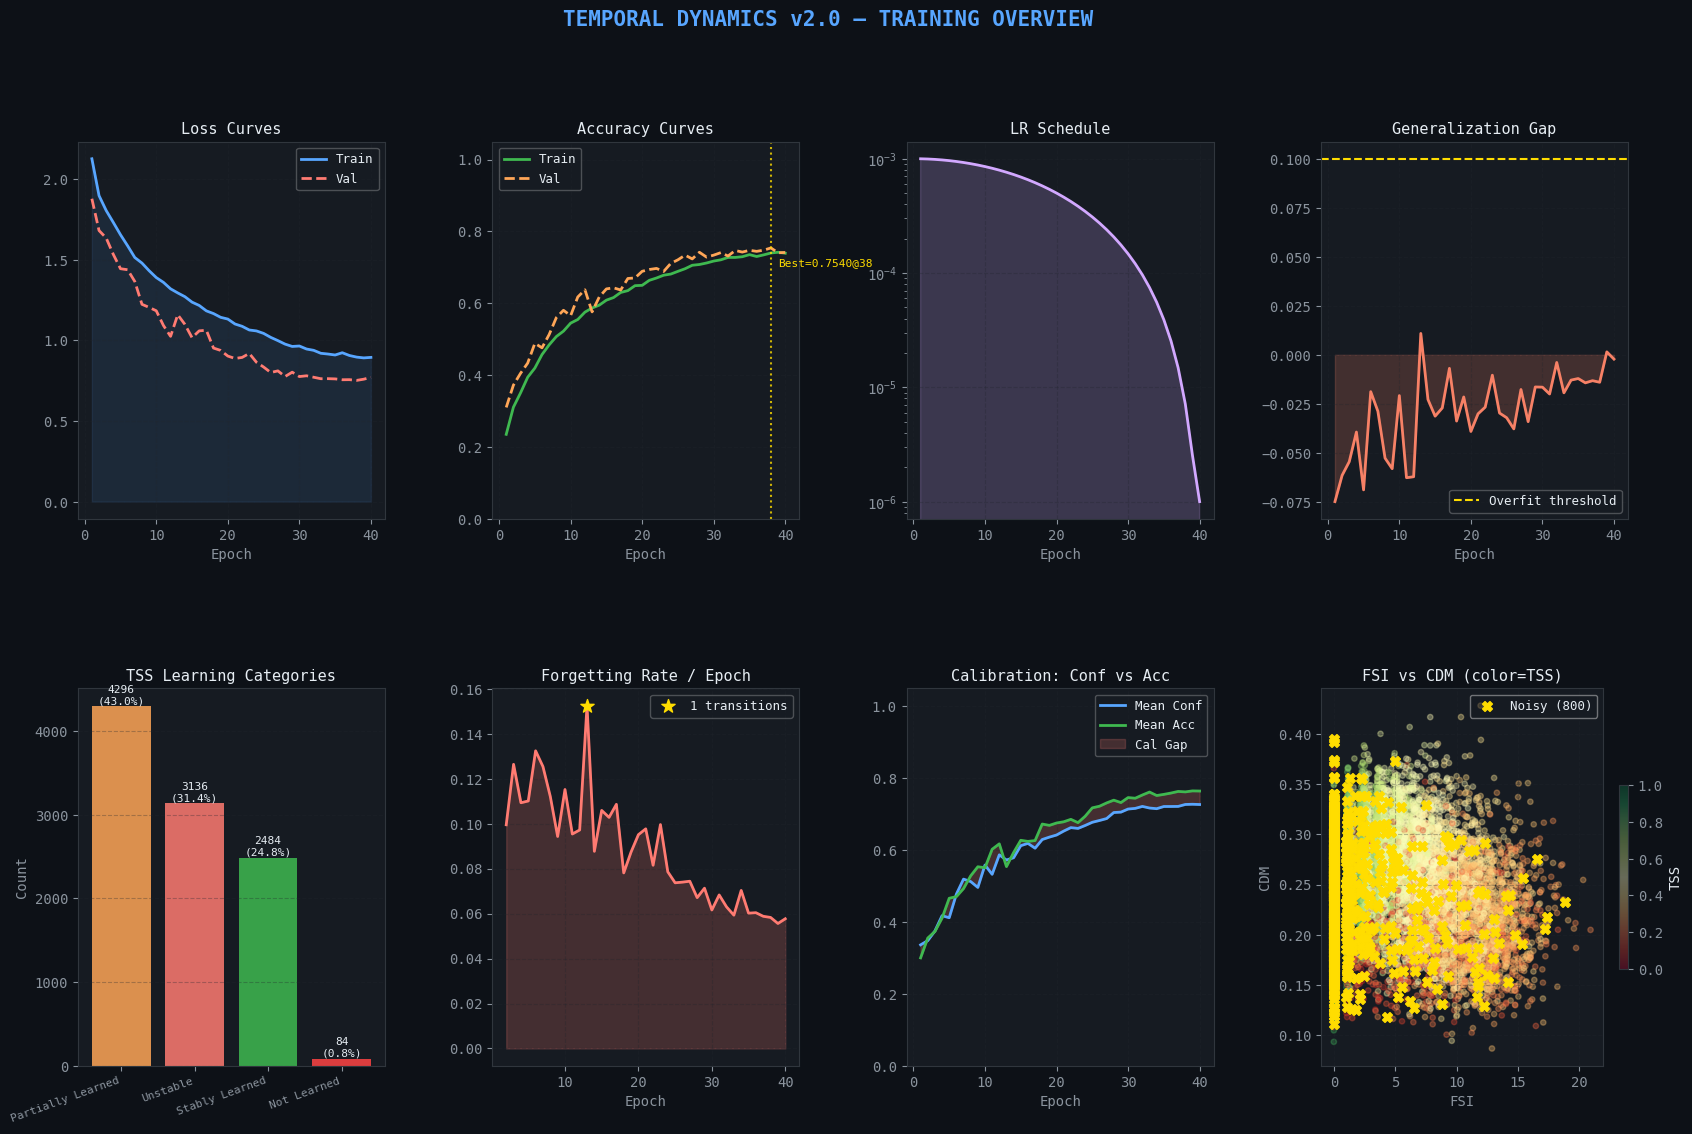

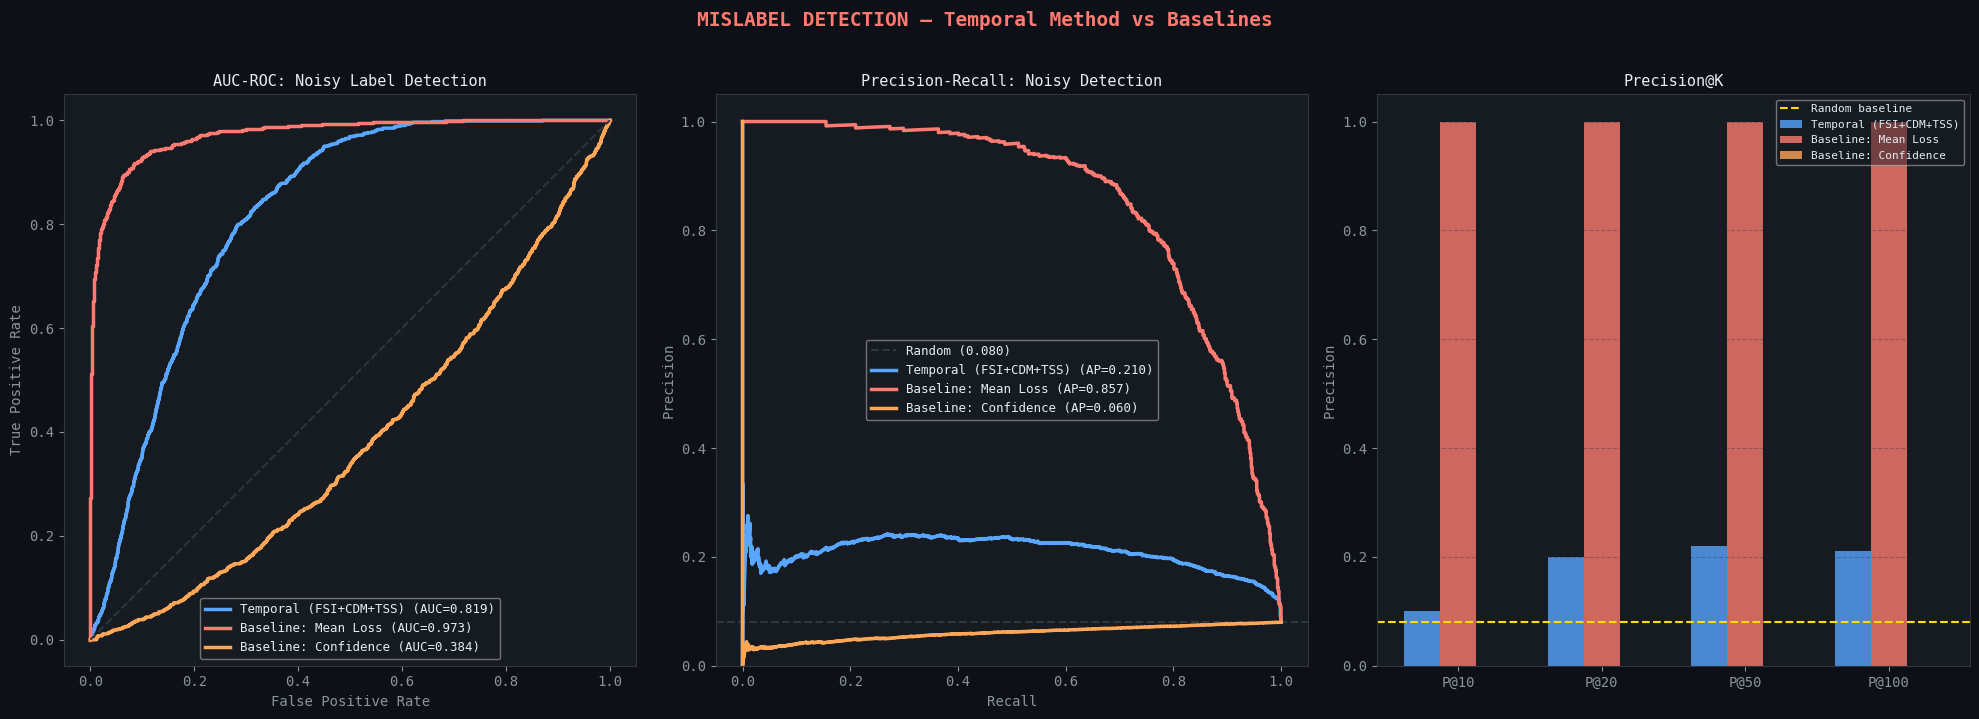

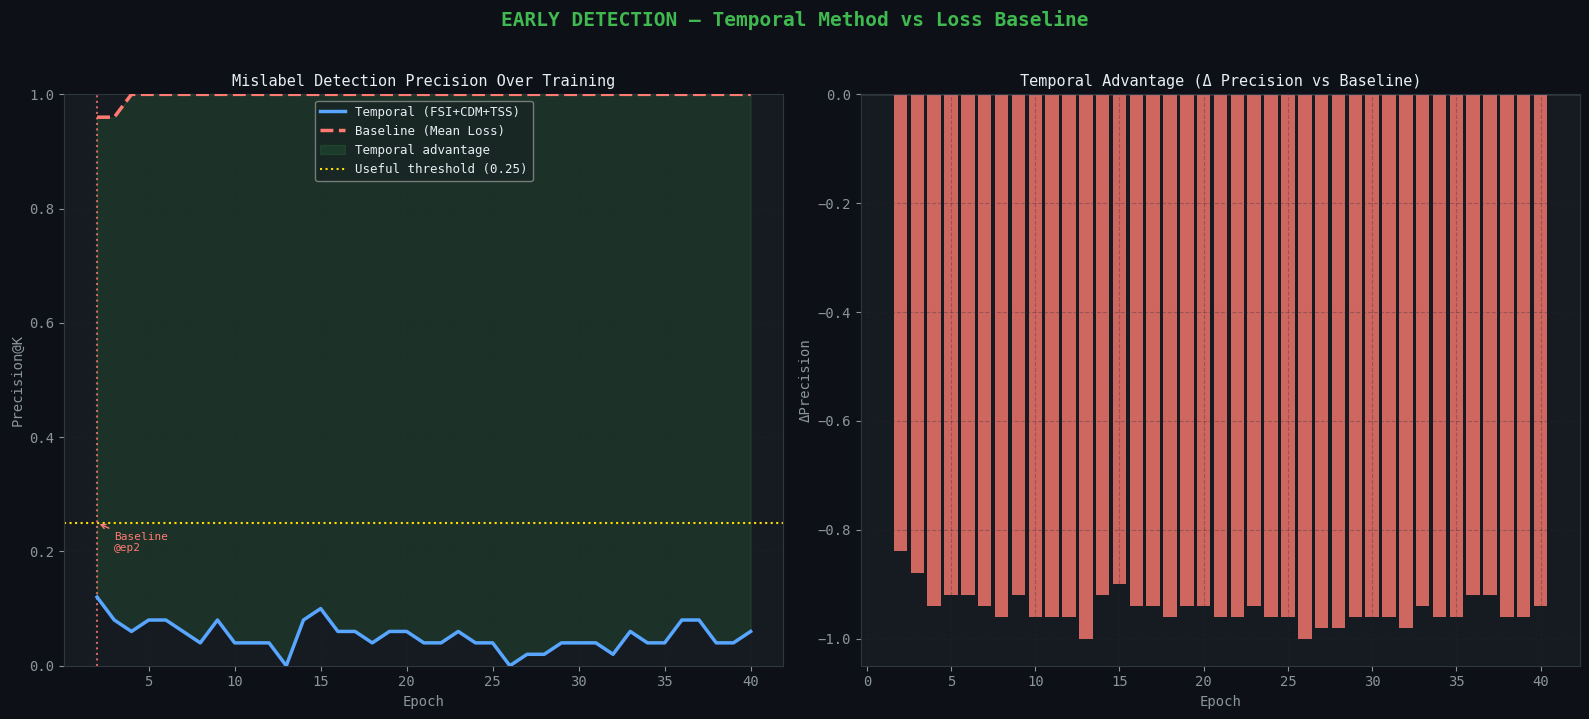

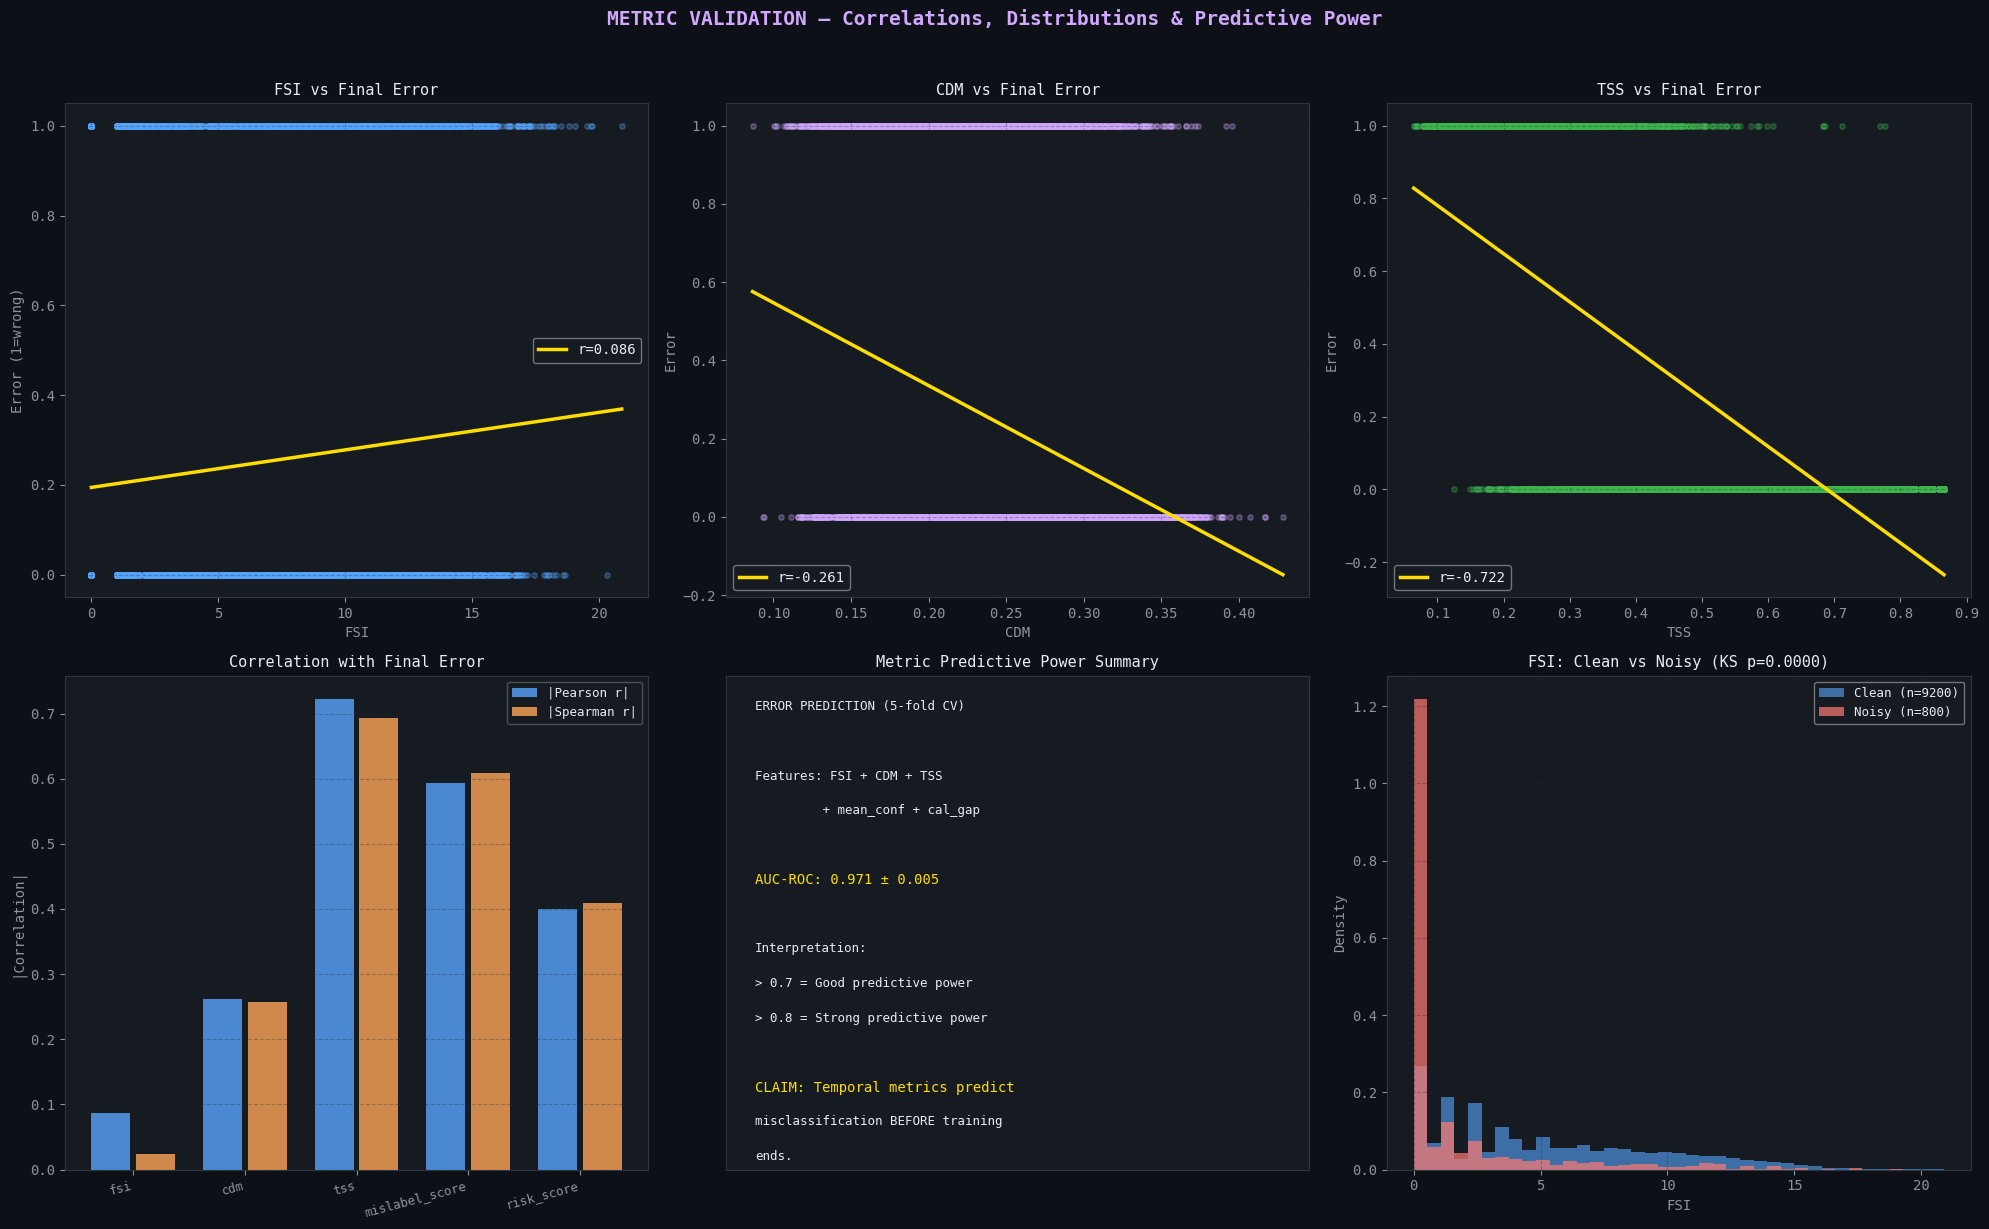

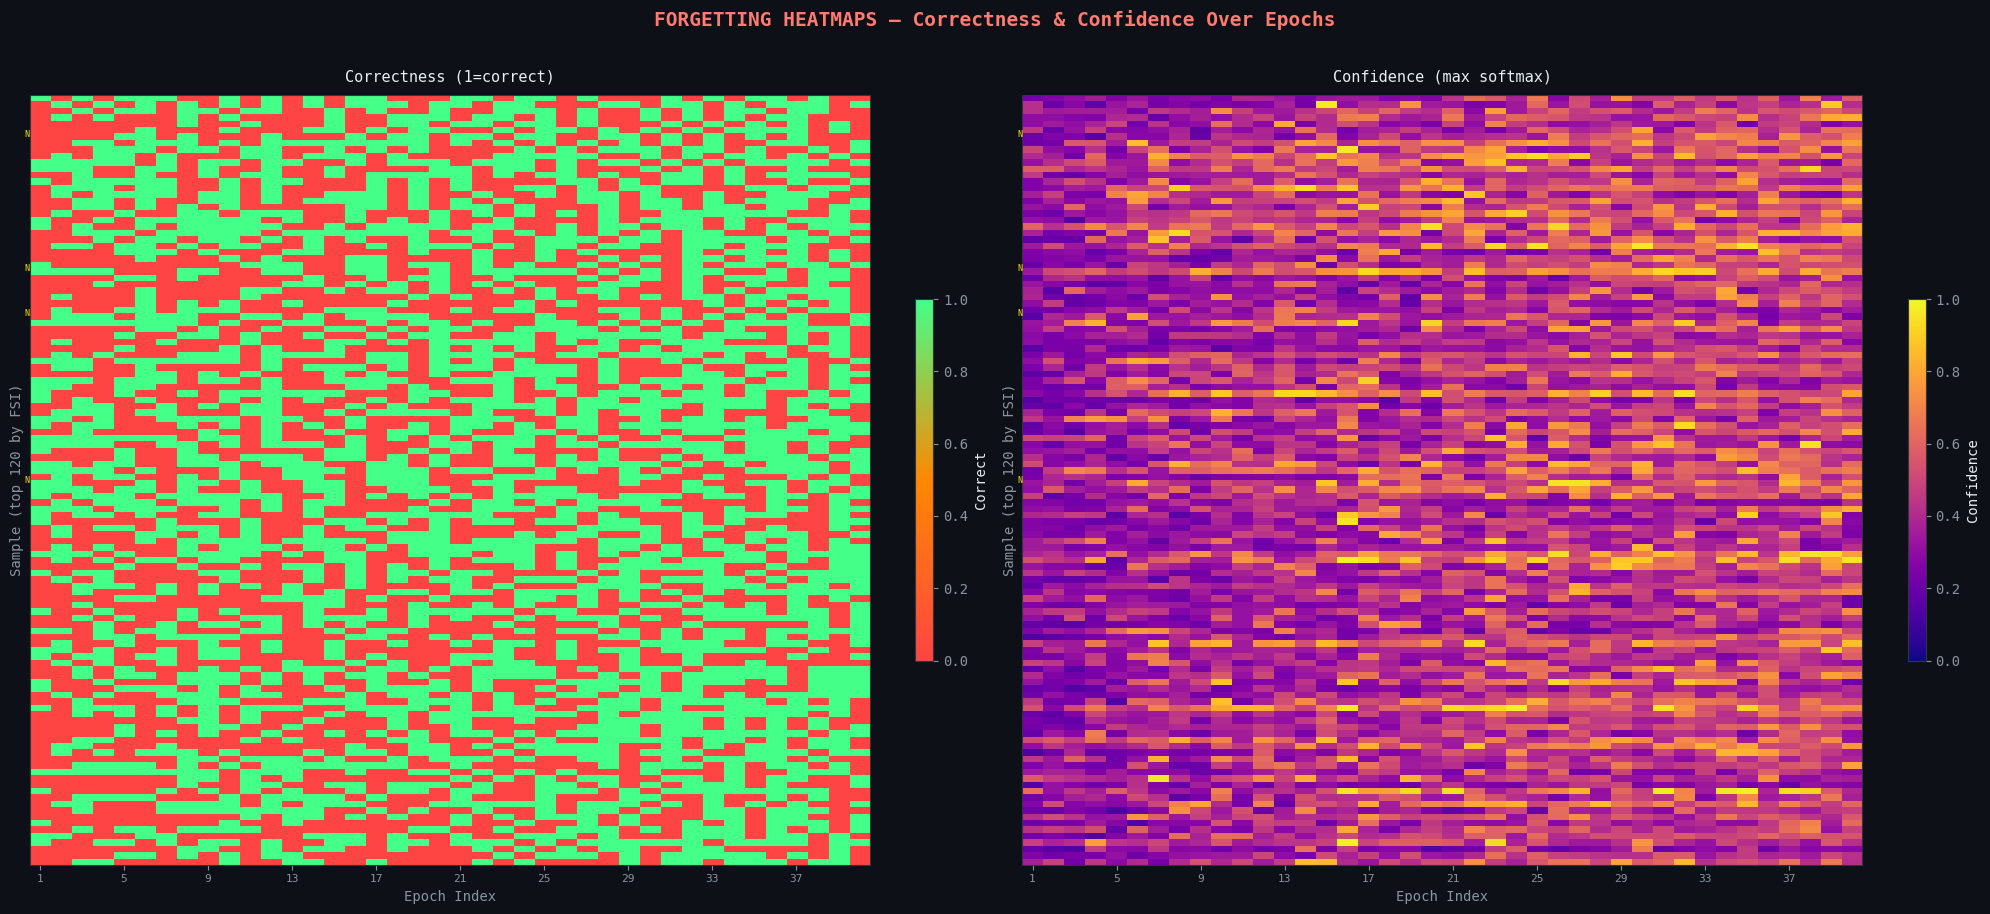

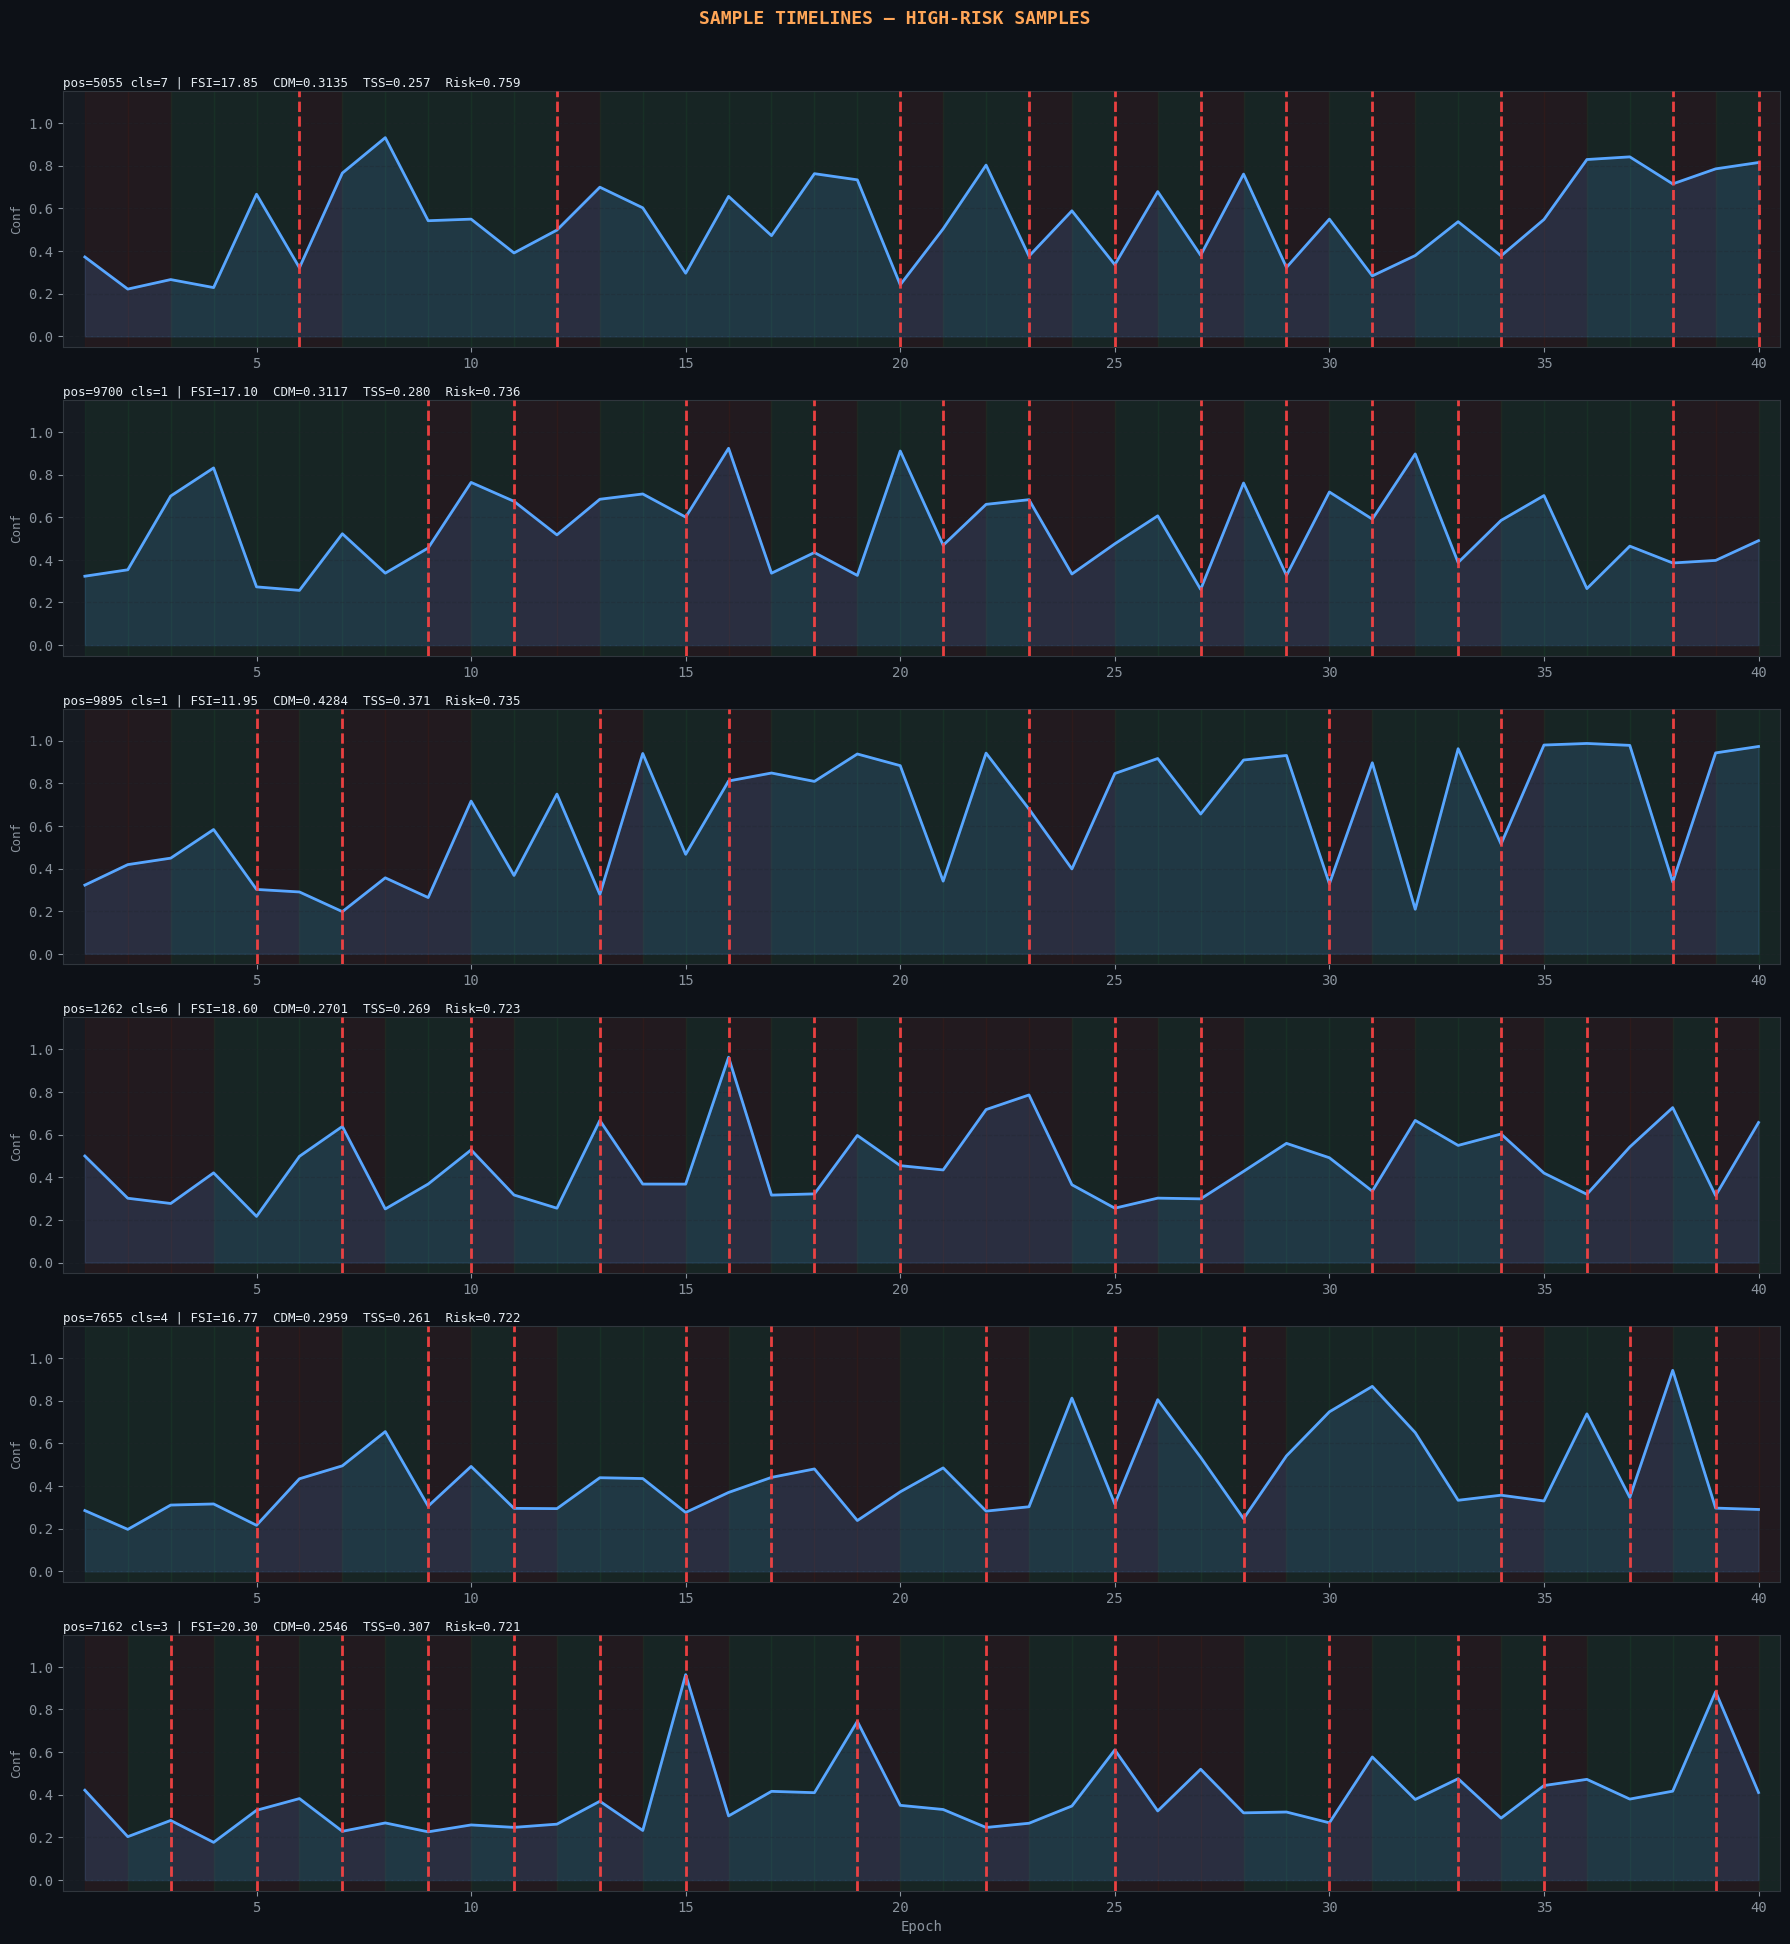

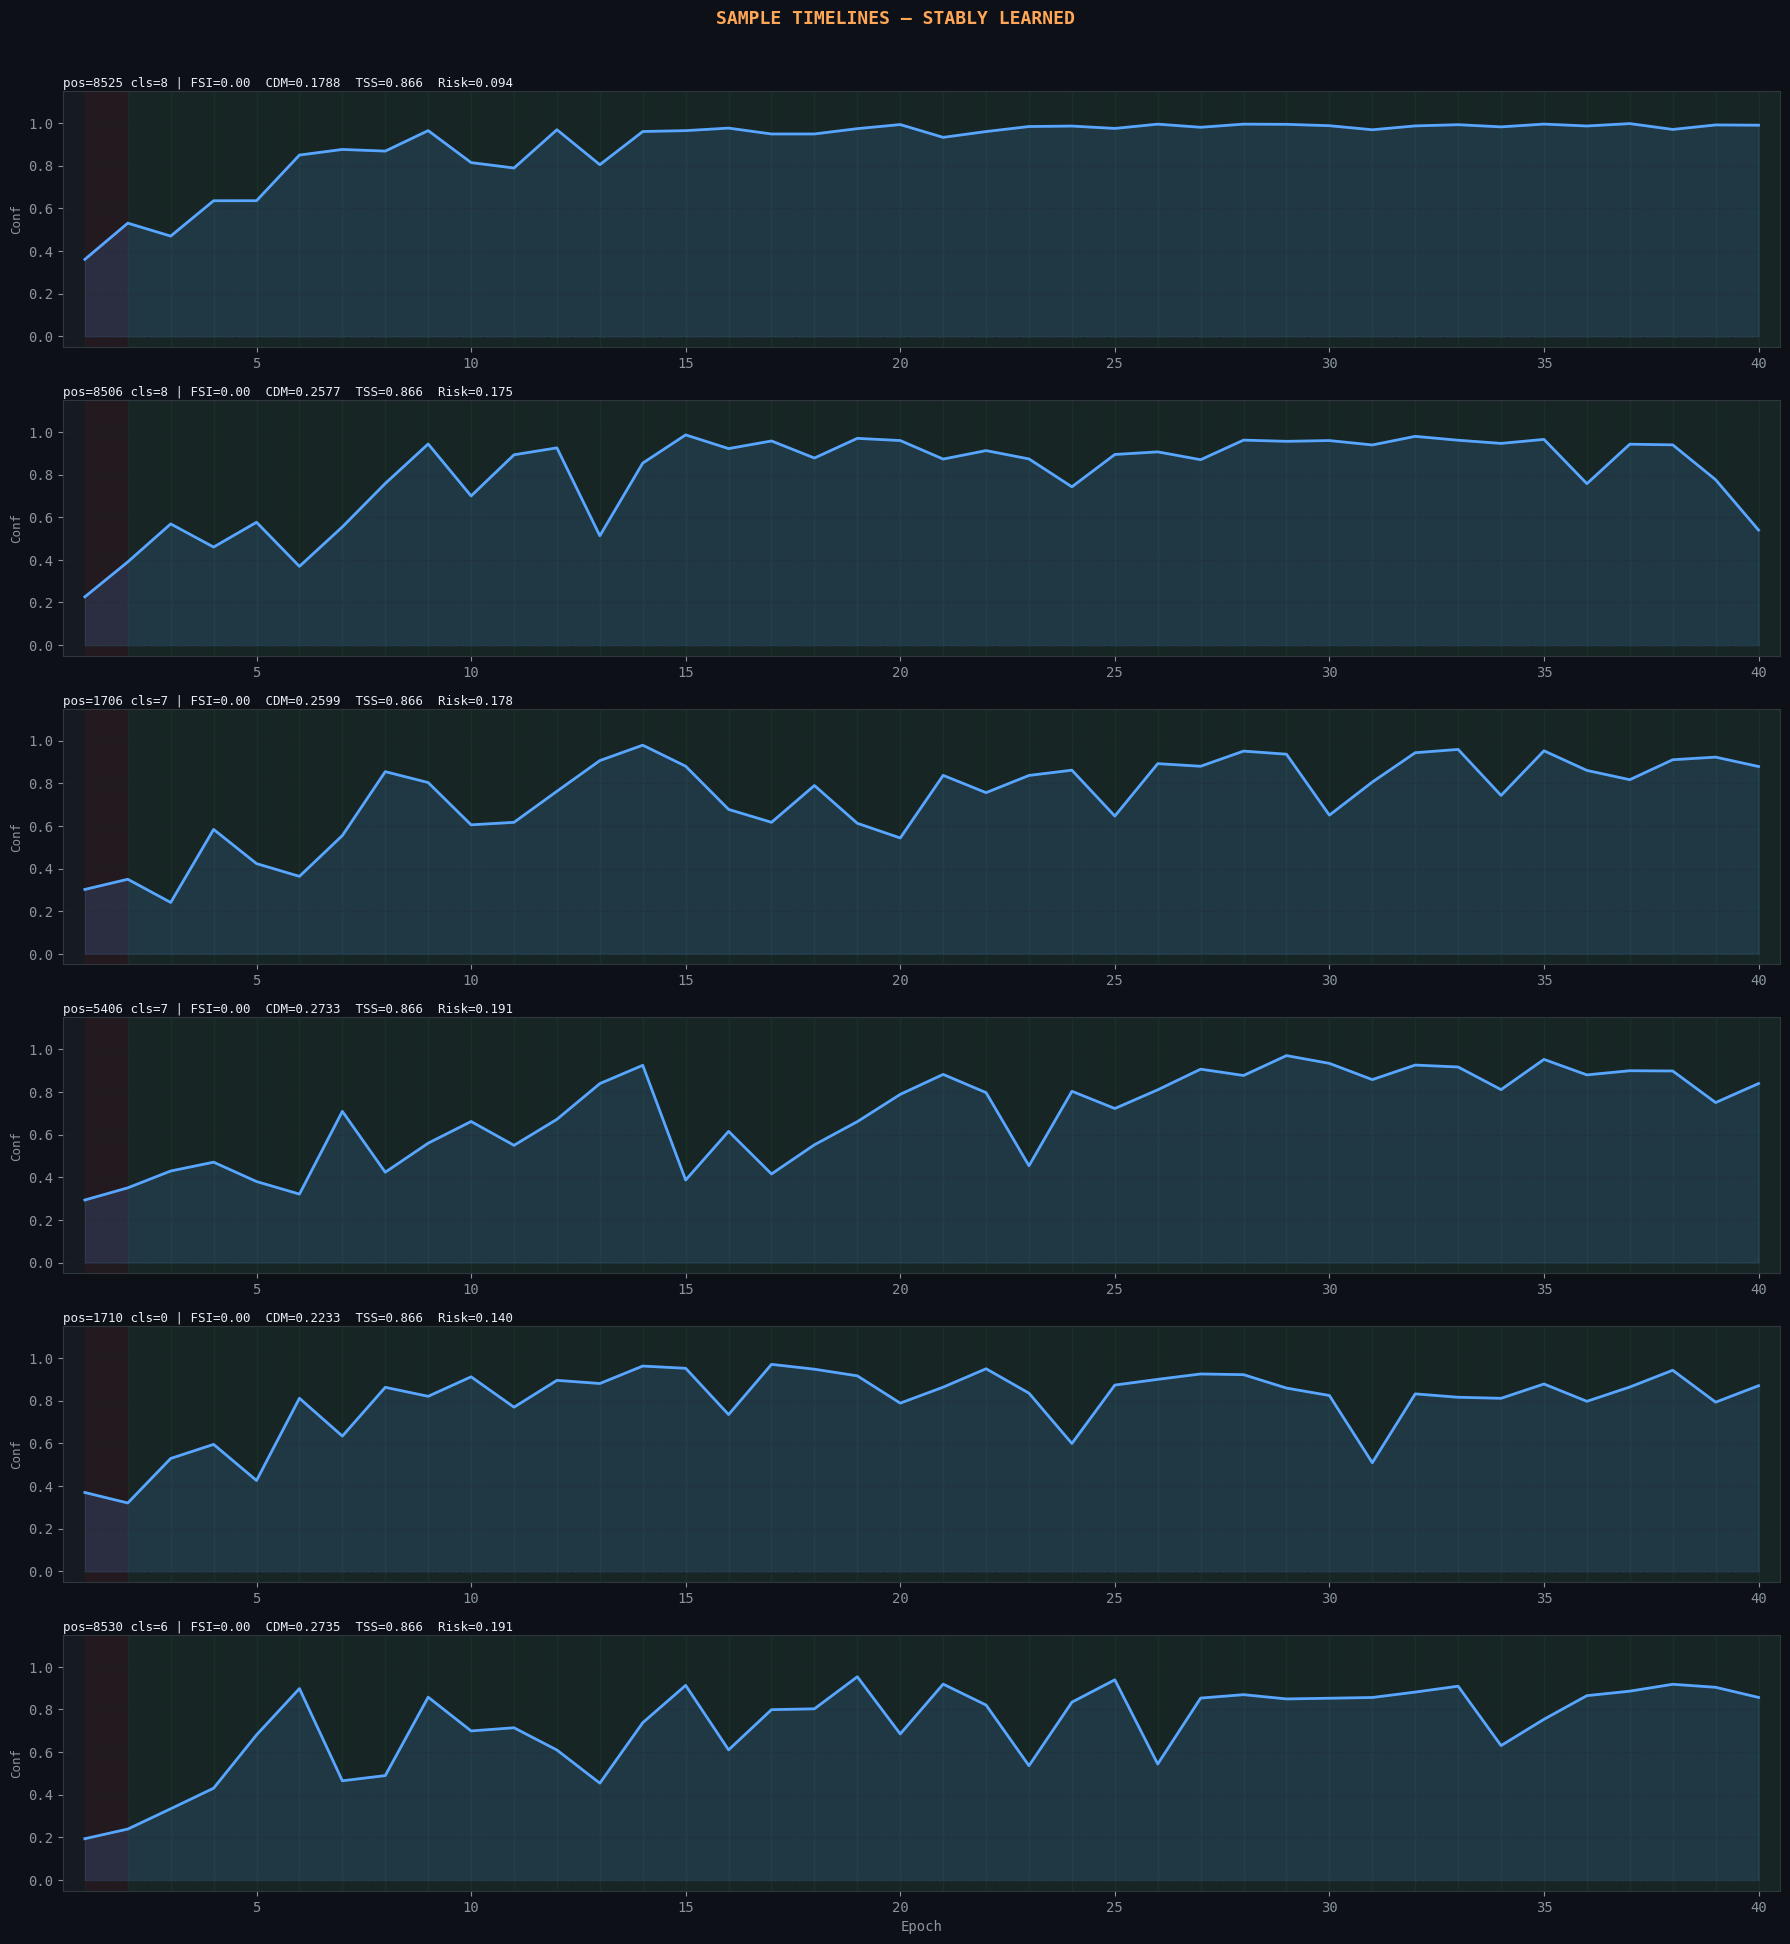

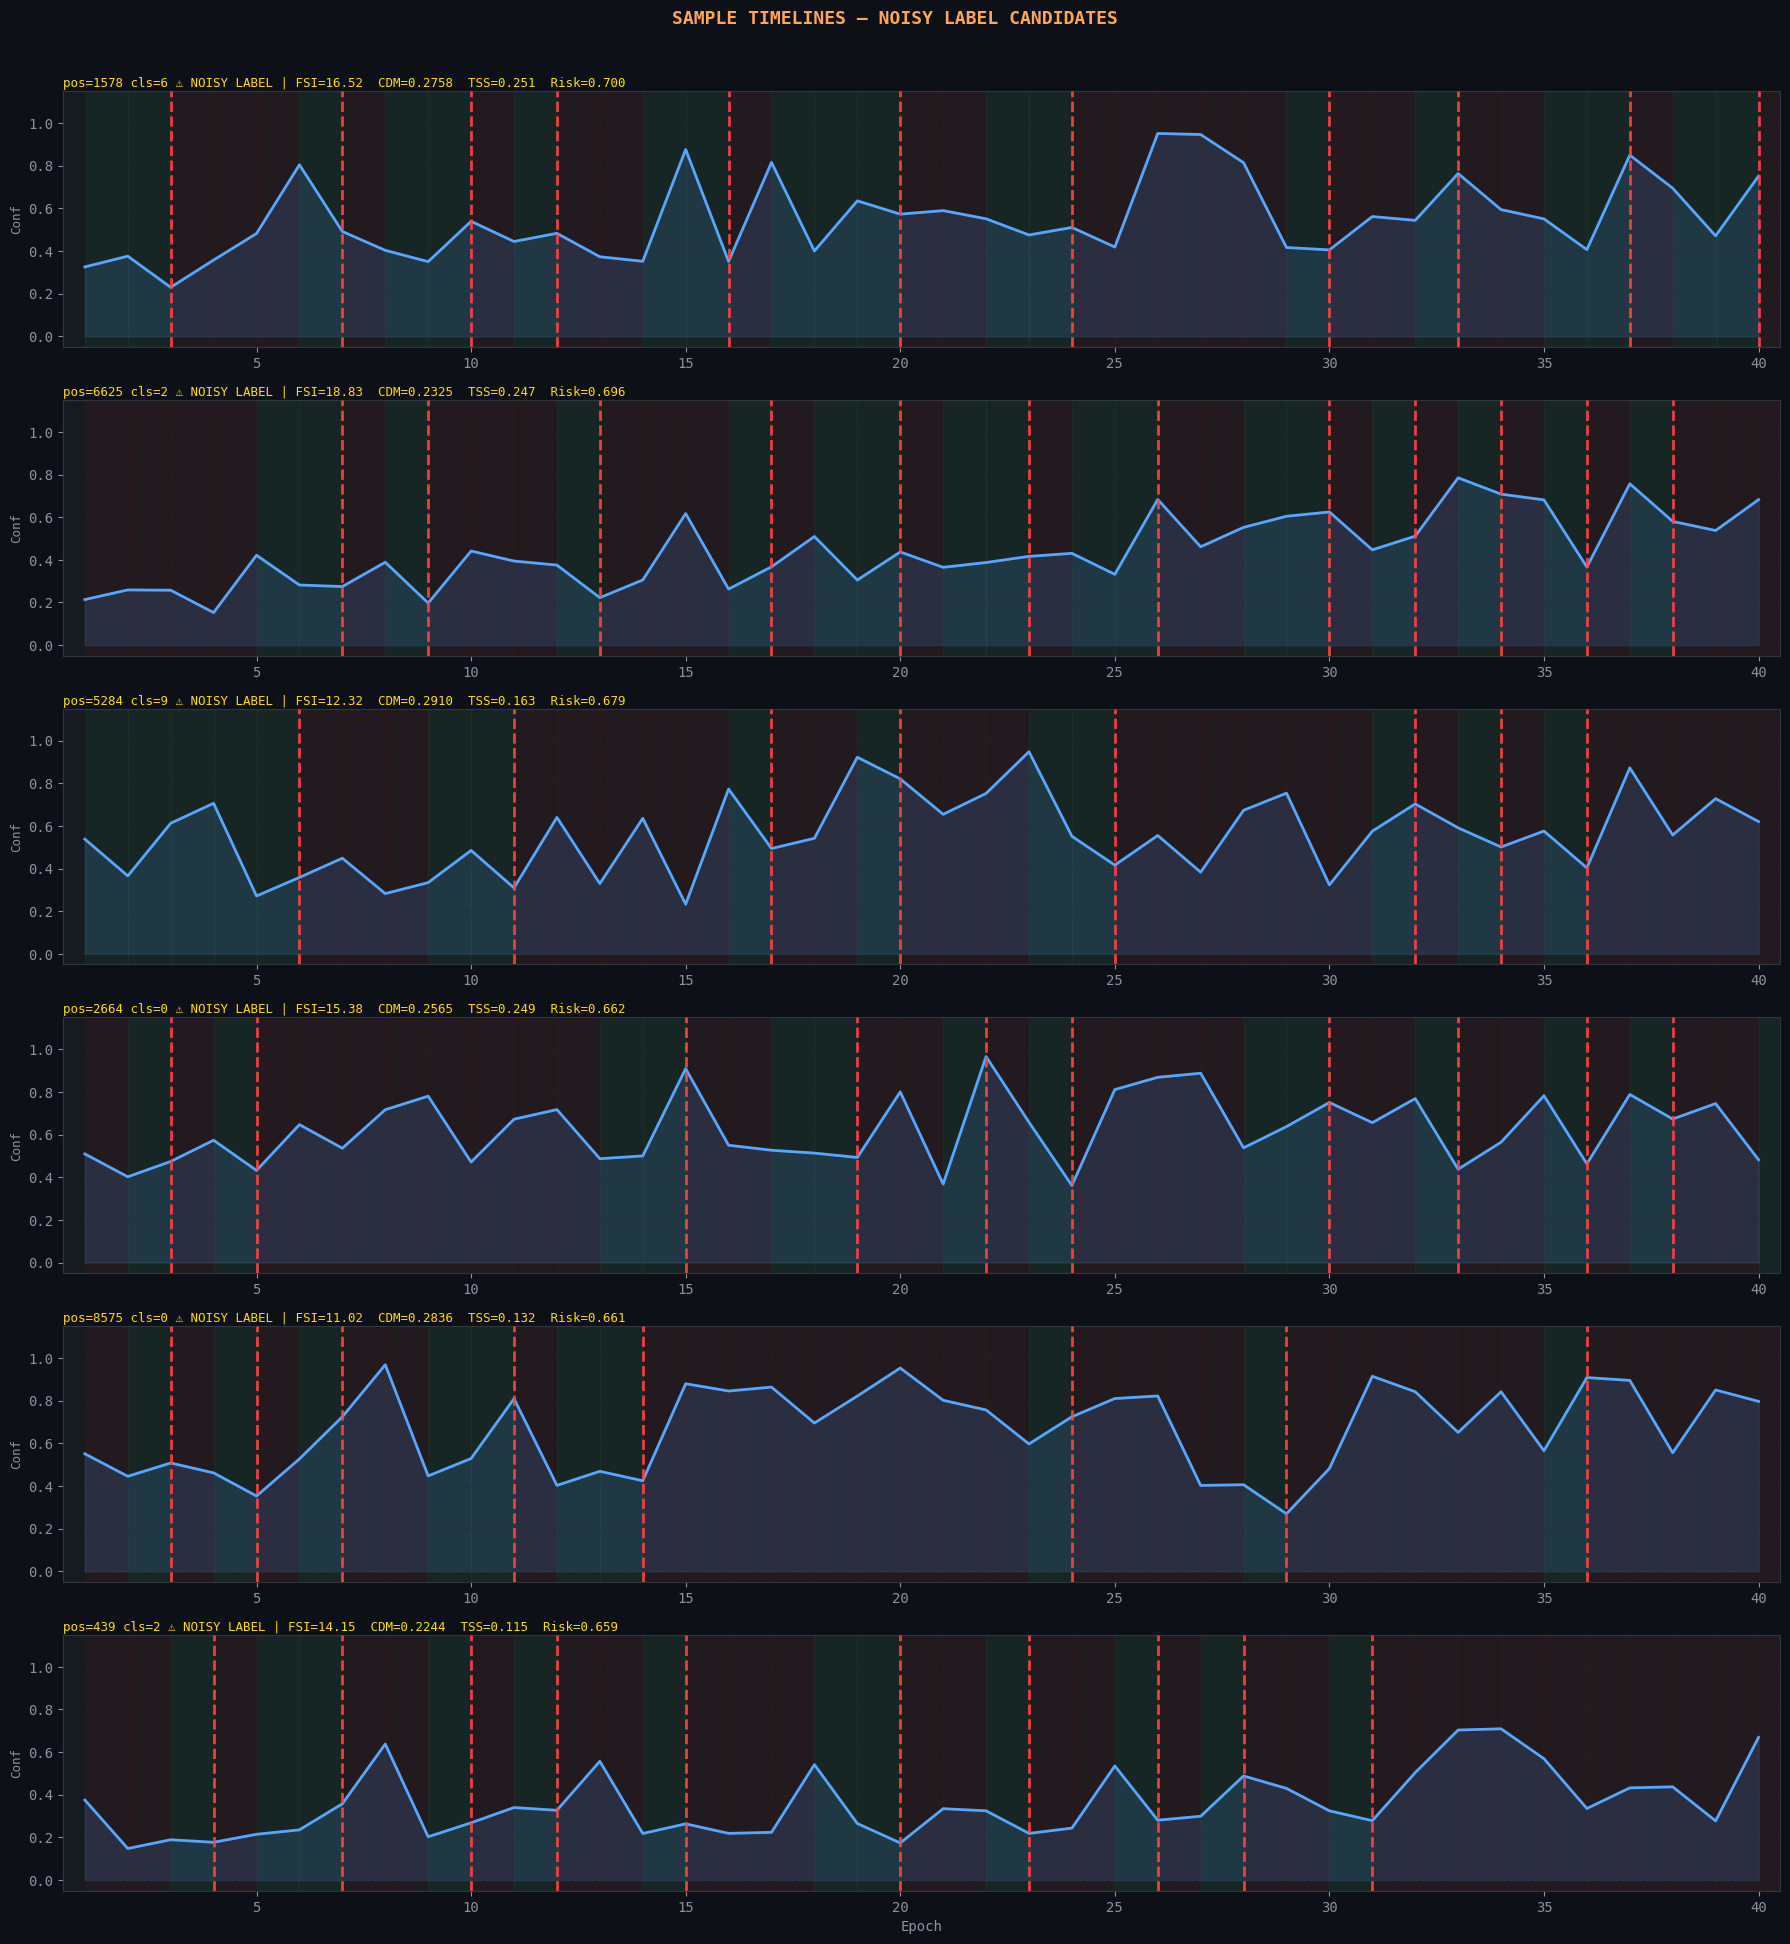

[VIZ-v2] Done — ./viz_v2/


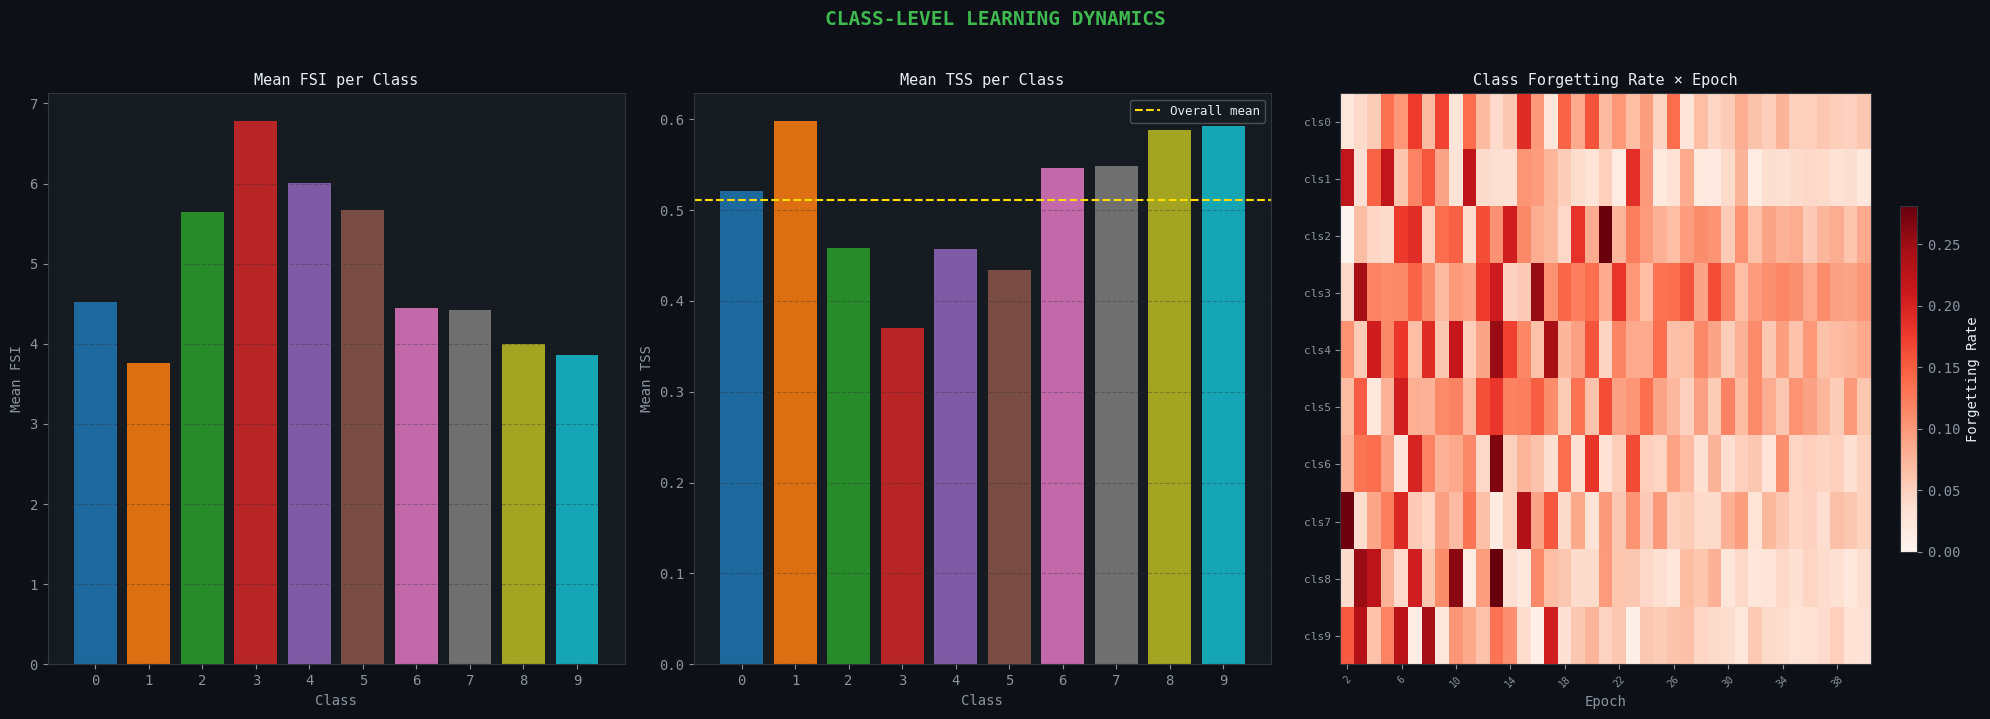


████████████████████████████████████████████████████████████████████████
  TEMPORAL LEARNING DYNAMICS FRAMEWORK v2.0
  RESEARCH DIAGNOSTIC REPORT
████████████████████████████████████████████████████████████████████████

  ▌ 1. TRAINING HEALTH
  ──────────────────────────────────────────
  Best val accuracy : 0.7540  @ epoch 38
  Final train acc   : 0.7393
  Final val acc     : 0.7415
  Gen. gap          : -0.0022  ✓ HEALTHY

  ▌ 2. FORGETTING SEVERITY INDEX (FSI)
  ──────────────────────────────────────────
  Mean FSI          : 4.912
  Max FSI           : 20.90
  High-FSI (>3)     : 5601 (56.0%)
  Most-forgotten cls: 3
  Corr w/ error     : r=0.086  p=0.0000  ✓ SIGNIFICANT

  ▌ 3. CONFIDENCE DRIFT METRIC (CDM)
  ──────────────────────────────────────────
  Mean CDM          : 0.24731
  High-drift (>0.15): 9682 (96.8%)
  Mean cal. gap     : 0.3538
  Corr w/ error     : r=-0.261  p=0.0000  ✓ SIGNIFICANT

  ▌ 4. TEMPORAL STABILITY SCORE (TSS)
  ──────────────────────────────────────────

In [ ]:

# =============================================================================
# SECTION 11: ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    # CIFAR-10 produces richer dynamics than MNIST (harder task → more forgetting)
    # For fast testing: dataset_name='MNIST', epochs=20
    results = run_pipeline_v2(dataset_name='CIFAR10', epochs=40)
    print("\n[DONE] Framework v2.0 completed. All plots in ./viz_v2/")
    print("\n  KEY RESULTS AVAILABLE:")
    print("  results['df']         — per-sample FSI, CDM, TSS, mislabel_score")
    print("  results['val_res']    — AUC-ROC, AP, P@K vs baselines")
    print("  results['corr_df']    — metric-error correlation stats")
    print("  results['error_pred'] — logistic regression AUC")
    print("  results['early_df']   — early detection timeline")
    print("  results['events_df']  — all forgetting/recovery events")